# Audio & Speech EDA

Label-free notebook for the first presentation. This version avoids candidate identification and focuses on:
- audio-feature correlation structure
- transcript word clouds
- transcript quality diagnostics
- non-alphabet / non-Latin noise detection
- Portuguese-dictionary coverage
- bigrams
- lexical richness

The candidate-identification notebook from the next project phase was preserved in `audio_eda/audio_candidate_analysis.ipynb`.


## 1. Setup and data loading


In [66]:
import math
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

FEATURES_DIR = '../Project_Features'


In [67]:
# ── Audio ─────────────────────────────────────────────────────────────────────
audio_files = sorted([f for f in os.listdir(FEATURES_DIR) if f.endswith('_audio.pkl')])
audio_dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_audio.pkl', '')
    audio_dfs.append(df)
data = pd.concat(audio_dfs, ignore_index=True)

def parse_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

data['speak_embeddings'] = data['speak_embeddings'].apply(parse_embedding)
META = ['video', 'time stamp', 'duration', 'speak_embeddings']
scalar_cols = [c for c in data.columns if c not in META]
debate_videos = sorted([v for v in data['video'].unique() if 'vs' in v])

# ── Speech / transcripts ───────────────────────────────────────────────────────
speech_files = sorted([f for f in os.listdir(FEATURES_DIR) if f.endswith('_speech.pkl')])
speech_dfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_speech.pkl', '')
    speech_dfs.append(df)
data_speech = pd.concat(speech_dfs, ignore_index=True)
data_speech['word_count'] = data_speech['transcript'].apply(
    lambda t: len(str(t).split()) if pd.notnull(t) else 0
)
data_speech['words_per_sec'] = data_speech['word_count'] / data_speech['duration']
speech_debates = data_speech[data_speech['video'].isin(debate_videos)].copy()

print(f'Audio segments  (all files): {len(data)}')
print(f'Speech segments (all files): {len(data_speech)}')
print(f'Debate videos: {len(debate_videos)}')
print(f'Scalar audio features: {len(scalar_cols)}')
print(f'Debate speech segments: {len(speech_debates)}')


Audio segments  (all files): 2656
Speech segments (all files): 1407
Debate videos: 28
Scalar audio features: 30
Debate speech segments: 843


## 1.1 Dataset overview & transcript quality diagnostics

Global stats and data-quality checks are run here — before any analysis — so every subsequent
section works with a clear understanding of the data. Includes:
- segment count and total speaking time per debate
- word-count and words-per-second distributions
- random character / non-Latin noise detection
- out-of-dictionary (non-Portuguese) token rate per segment
- filtering decision summary

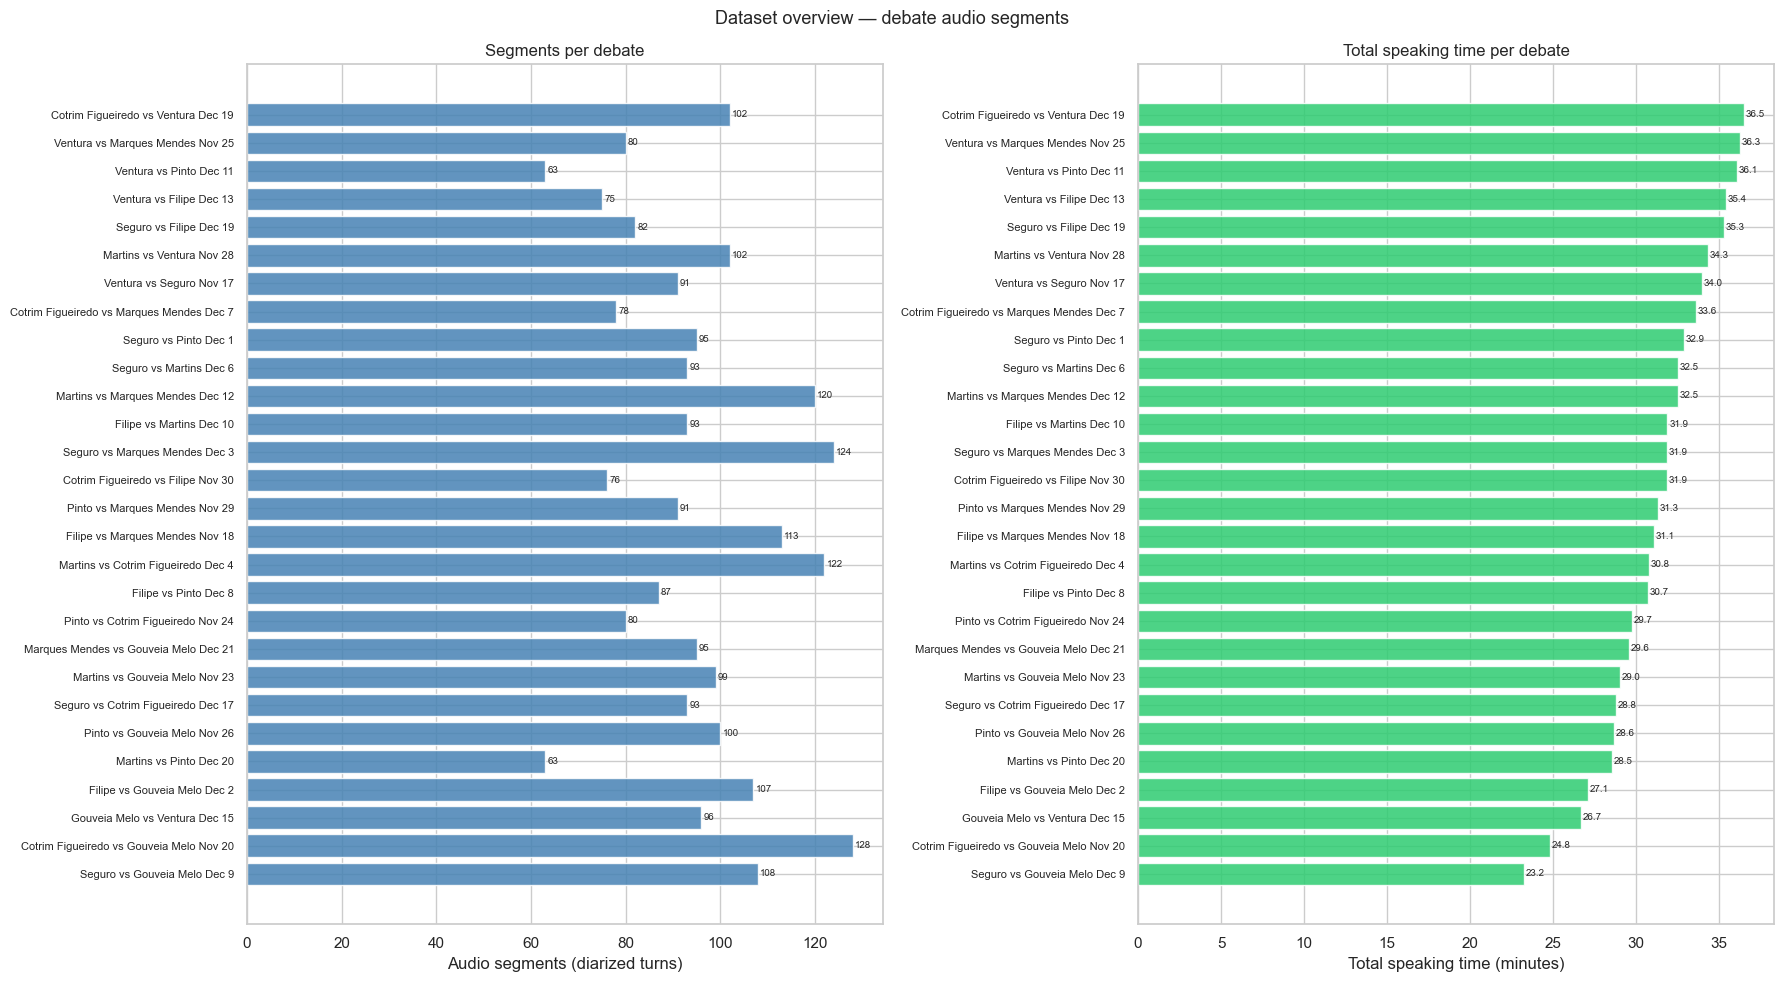

Total debates: 28
Total audio segments: 2656
Total audio duration: 14.58 h
Total speech segments: 843
Portuguese dictionary backend: spylls: pt_PT.dic


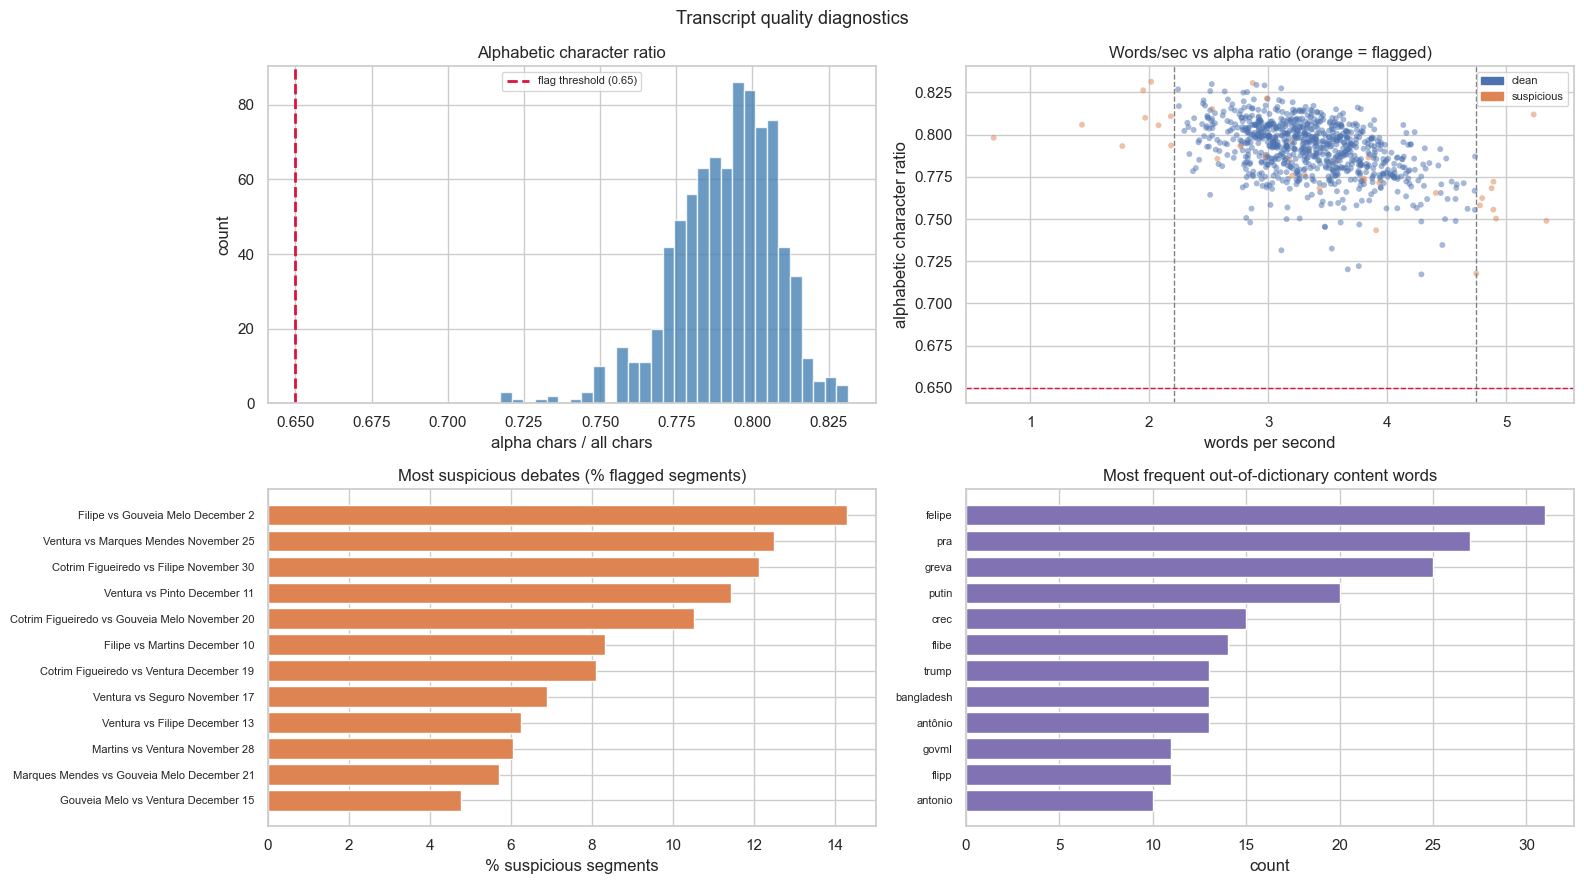

Examples of suspicious segments:


,video,duration,words_per_sec,alpha_ratio,ood_ratio,ood_examples,transcript_str
1,Cotrim_Figueiredo_vs_Filipe_November_30,44.972,3.201992,0.795799,0.419355,"itaí, pegueiro, cookiecutei, absorbed, dúf, na...","O da Itaí�� e Pegueiro,しく cookiecutei depois,..."
16,Cotrim_Figueiredo_vs_Filipe_November_30,58.944,3.036781,0.795741,0.287356,"estaba, fer, dua, pagoarem, trucks, twin","mas essa pessoa não tem capacidade económica,..."
27,Cotrim_Figueiredo_vs_Filipe_November_30,36.399,3.544053,0.783934,0.127660,"migrão, transjeros, felipe, lígidas, birdas, c...","Mas eu estou tão preocupado, os caras mais pr..."
28,Cotrim_Figueiredo_vs_Filipe_November_30,34.374,2.530983,0.815217,0.175000,"assiuristas, carreras, palestração, sementemco...",Os senhores dos assiuristas das empresas. Os ...
34,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,24.907,1.967318,0.810000,0.095238,contatos,no encontro de soluções que o presidente deve...
48,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,29.632,5.230832,0.811957,0.246154,"imensência, panemias, ordenamente, forços, tap...",que os liberais vão defender o papel do Estad...



──────────────────────────────────────────────────────────────
FILTERING DECISION
──────────────────────────────────────────────────────────────
Flagged segments: 38 / 843  (4.5%)
Words in flagged segments: 5619 / 117328  (4.8%)

Option A  Keep all — safest for audio/embedding analysis.
          Non-PT words only pollute text sections (word clouds,
          bigrams, lexical richness) which already use stopword lists.

Option B  Filter suspicious segments from TEXT analysis only
          (word clouds, bigrams, lexical richness) but keep for audio.
          → Recommended: low cost, clean text, no audio data loss.

Option C  Drop flagged segments entirely from both audio and text.
          Only if flagged segments are mostly noise (check examples above).
──────────────────────────────────────────────────────────────


In [68]:
# ── a) Dataset overview: segments & speaking time per video (debates + newscasts) ──
# Speech segments exist for every video; audio (diarized) segments only exist for debates.
def label_source(video):
    return 'News reports' if str(video).startswith('Telejornal_') else 'Debates'

video_stats = (
    data_speech.groupby('video')
    .agg(n_speech_segs=('duration', 'size'), total_speech_s=('duration', 'sum'))
    .reset_index()
)
video_stats['source_group'] = video_stats['video'].apply(label_source)
video_stats['label'] = (
    video_stats['video']
    .str.replace('_vs_', ' vs ').str.replace('_', ' ')
    .str.replace('November', 'Nov').str.replace('December', 'Dec')
    .str.replace('October', 'Oct').str.replace('January', 'Jan')
    .str.replace('Telejornal ', '')
)

# Merge in audio (diarized) segment counts where available — debates only.
audio_seg_counts = (
    data.groupby('video').size().rename('n_audio_segs').reset_index()
)
video_stats = video_stats.merge(audio_seg_counts, on='video', how='left')

# Sort: News reports above Debates, each group ordered by speaking time.
video_stats = video_stats.sort_values(['source_group', 'total_speech_s'],
                                      ascending=[False, True]).reset_index(drop=True)

source_color = {'Debates': 'steelblue', 'News reports': 'darkorange'}
bar_colors = [source_color[s] for s in video_stats['source_group']]

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

axes[0].barh(video_stats['label'], video_stats['n_speech_segs'],
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Speech segments (Whisper-transcribed turns)')
axes[0].set_title('Speech segments per video (debates + newscasts)')
axes[0].tick_params(axis='y', labelsize=7)
for bar, val in zip(axes[0].patches, video_stats['n_speech_segs']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 str(int(val)), va='center', fontsize=6)

axes[1].barh(video_stats['label'], video_stats['total_speech_s'] / 60,
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Total speaking time (minutes)')
axes[1].set_title('Total speaking time per video (debates + newscasts)')
axes[1].tick_params(axis='y', labelsize=7)
for bar, val in zip(axes[1].patches, video_stats['total_speech_s']):
    axes[1].text(val / 60 + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val/60:.1f}', va='center', fontsize=6)

from matplotlib.patches import Patch as _OvPatch
legend_handles = [_OvPatch(color=c, label=s) for s, c in source_color.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Dataset overview — speech segments and speaking time per video', fontsize=13)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

# Group totals.
group_totals = (video_stats.groupby('source_group')
                .agg(videos=('video', 'nunique'),
                     speech_segments=('n_speech_segs', 'sum'),
                     speech_minutes=('total_speech_s', lambda s: s.sum() / 60),
                     audio_segments=('n_audio_segs', lambda s: s.fillna(0).sum()))
                .round(1))
print('Group totals:')
print(group_totals.to_string())
print()
print(f'Total videos:           {len(video_stats)}  (debates + newscasts)')
print(f'Total speech segments:  {int(video_stats["n_speech_segs"].sum())}')
print(f'Total speaking time:    {video_stats["total_speech_s"].sum()/3600:.2f} h')
print(f'Audio (diarized) segments — debates only: {int(video_stats["n_audio_segs"].fillna(0).sum())}')

# Keep `audio_stats` defined for downstream debate-only sections (correlations, clustering).
audio_stats = video_stats[video_stats['source_group'] == 'Debates'].rename(
    columns={'n_audio_segs': 'n_segments', 'total_speech_s': 'total_duration_s'}
)[['video', 'label', 'n_segments', 'total_duration_s', 'n_speech_segs']].copy()
audio_stats['n_segments'] = audio_stats['n_segments'].fillna(0).astype(int)
audio_stats = audio_stats.sort_values('total_duration_s').reset_index(drop=True)

# ── b) Stopwords & helper functions (used in quality diagnostics + all text sections) ──
PT_STOPWORDS = {
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'uma',
    'com', 'não', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao',
    'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito',
    'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até',
    'isso', 'ela', 'entre', 'era', 'depois', 'sem', 'mesmo', 'aos', 'seus',
    'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram',
    'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'têm', 'numa',
    'pelos', 'pelas', 'qual', 'nós', 'lhe', 'deles', 'essas', 'esses',
    'pois', 'se', 'si', 'nessa', 'nesse', 'todo', 'toda', 'tudo', 'isto',
    'aqui', 'aquele', 'aquela', 'vos', 'lhes', 'cujo', 'cuja', 'nele',
    'dele', 'delas', 'nela', 'nos', 'na', 'no', 'ter', 'this', 'the',
    'são', 'este', 'esta', 'boa', 'noite', 'então', 'assim',
    'porque', 'temos', 'sobre', 'agora', 'bem', 'vai', 'pode',
    'vou', 'acho', 'anos', 'dizer', 'fazer', 'haver',
    'coisa', 'coisas', 'aquilo', 'portanto', 'aliás', 'claro', 'sim',
    'nada', 'nunca', 'sempre', 'ainda', 'hoje',
    'estou', 'estamos', 'estava', 'vamos', 'vão', 'sou', 'sabe', 'sei',
    'quer', 'quero', 'querem', 'podemos', 'deve', 'falar', 'faz', 'fez',
    'disse', 'diz', 'ver', 'dar', 'estar', 'sendo', 'tendo', 'sido',
    'pessoa', 'pessoas', 'gente', 'lado', 'parte', 'forma', 'vez', 'caso',
    'ponto', 'sentido', 'tempo', 'momento', 'exemplo', 'questão', 'verdade',
    'nosso', 'nossa', 'todos', 'outro', 'outros', 'outra',
    'alguém', 'ninguém', 'qualquer', 'mim', 'dois'
}

CUSTOM_PT_ALLOWLIST = {
    'gouveia', 'melo', 'gouveia-melo', 'marques', 'mendes', 'cotrim', 'figueiredo',
    'ventura', 'seguro', 'filipe', 'martins', 'pinto', 'ps', 'psd', 'cds', 'ch',
    'il', 'cdu', 'be', 'rtp', 'tvi', 'sic'
}
CUSTOM_PT_ALLOWLIST_PATHS = [
    Path('pt_custom_allowlist.txt'),
    Path('audio_eda/pt_custom_allowlist.txt'),
]


def clean_transcript_for_eda(text):
    text = str(text).lower()
    return re.sub(r'\s+', ' ', text).strip()


def tokenize_transcript(text, stopwords=None, min_len=3):
    stopwords = set() if stopwords is None else set(stopwords)
    tokens = re.findall(r"[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?",
                        clean_transcript_for_eda(text), flags=re.IGNORECASE)
    return [t for t in tokens if len(t) >= min_len and t not in stopwords]


def tokenize_for_dictionary(text):
    return re.findall(r"[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?",
                      clean_transcript_for_eda(text), flags=re.IGNORECASE)


def tokenize_for_dictionary_content(text):
    return tokenize_transcript(text, stopwords=PT_STOPWORDS, min_len=3)


def has_non_latin_script(text):
    return any(
        any(tag in unicodedata.name(ch, '')
            for tag in ('CYRILLIC', 'HIRAGANA', 'KATAKANA', 'CJK UNIFIED'))
        for ch in str(text)
    )


def strip_accents(text):
    return ''.join(
        ch for ch in unicodedata.normalize('NFD', str(text))
        if unicodedata.category(ch) != 'Mn'
    )


def load_custom_allowlist(paths):
    words = set()
    for path in paths:
        if path.exists():
            for line in path.read_text(encoding='utf-8', errors='ignore').splitlines():
                word = line.strip().lower()
                if word and not word.startswith('#'):
                    words.add(word)
    return words


def load_exact_wordlist(path):
    path = Path(path)
    lines = path.read_text(encoding='utf-8', errors='ignore').splitlines()
    if lines and lines[0].strip().isdigit():
        lines = lines[1:]
    words = set()
    for line in lines:
        word = line.split('/', 1)[0].strip().lower()
        if re.fullmatch(r"[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?", word, flags=re.IGNORECASE):
            words.add(word)
    return words


def build_portuguese_checker():
    hunspell_candidates = [
        (Path('pt_PT.dic'), Path('pt_PT.aff')),
        (Path('pt-PT.dic'), Path('pt-PT.aff')),
        (Path('portuguese.dic'), Path('portuguese.aff')),
        (Path('/usr/share/hunspell/pt_PT.dic'), Path('/usr/share/hunspell/pt_PT.aff')),
        (Path('/usr/share/hunspell/pt-PT.dic'), Path('/usr/share/hunspell/pt-PT.aff')),
        (Path('/usr/share/hunspell/pt_BR.dic'), Path('/usr/share/hunspell/pt_BR.aff')),
    ]
    for dic_path, aff_path in hunspell_candidates:
        if dic_path.exists() and aff_path.exists():
            stem_words = {w.lower() for w in load_exact_wordlist(dic_path)}
            stem_words_folded = {strip_accents(w) for w in stem_words}

            def fallback(token, s=stem_words, sf=stem_words_folded):
                low = str(token).lower()
                return (low in s) or (strip_accents(low) in sf)

            try:
                from spylls.hunspell import Dictionary
                spell = Dictionary.from_files(str(dic_path.with_suffix('')))

                def spylls_check(token, sp=spell, fb=fallback):
                    return any(bool(sp.lookup(v))
                               for v in [token, token.lower(), token.title(), token.upper()]) or fb(token)
                return spylls_check, f'spylls: {dic_path}'
            except Exception:
                try:
                    import hunspell as hs
                    spell = hs.HunSpell(str(dic_path), str(aff_path))

                    def hunspell_check(token, sp=spell, fb=fallback):
                        return any(sp.spell(v)
                                   for v in [token, token.lower(), token.title(), token.upper()]) or fb(token)
                    return hunspell_check, f'hunspell: {dic_path}'
                except Exception:
                    pass

    for txt_path in [Path('portuguese_words.txt'), Path('pt_words.txt'), Path('pt_PT.txt')]:
        if txt_path.exists():
            words = {w.lower() for w in load_exact_wordlist(txt_path)}
            words_folded = {strip_accents(w) for w in words}

            def plain_check(token, ws=words, wsf=words_folded):
                low = str(token).lower()
                return (low in ws) or (strip_accents(low) in wsf)
            return plain_check, f'plain word list: {txt_path}'

    try:
        from wordfreq import zipf_frequency
        return lambda token: zipf_frequency(token, 'pt') > 0, 'wordfreq fallback'
    except Exception:
        return None, 'no Portuguese dictionary backend found'


def unique_preview(tokens, n=6):
    seen = []
    for tok in tokens:
        if tok not in seen:
            seen.append(tok)
        if len(seen) >= n:
            break
    return ', '.join(seen)


CUSTOM_PT_ALLOWLIST |= load_custom_allowlist(CUSTOM_PT_ALLOWLIST_PATHS)
CUSTOM_PT_ALLOWLIST_FOLDED = {strip_accents(w) for w in CUSTOM_PT_ALLOWLIST}


def is_portuguese_token(token, checker):
    token = str(token).lower()
    if token in CUSTOM_PT_ALLOWLIST or strip_accents(token) in CUSTOM_PT_ALLOWLIST_FOLDED:
        return True
    if checker is None:
        return None
    if checker(token):
        return True
    if '-' in token:
        parts = [p for p in token.split('-') if p]
        if parts and all((p in CUSTOM_PT_ALLOWLIST) or checker(p) for p in parts):
            return True
    return False


# ── c) Quality diagnostics ────────────────────────────────────────────────────
speech_quality = speech_debates.copy()
speech_quality['transcript_str'] = speech_quality['transcript'].astype(str)
speech_quality['char_count'] = speech_quality['transcript_str'].str.len()
speech_quality['alpha_chars'] = speech_quality['transcript_str'].apply(
    lambda t: sum(ch.isalpha() for ch in str(t))
)
speech_quality['alpha_ratio'] = speech_quality['alpha_chars'] / speech_quality['char_count'].clip(lower=1)
speech_quality['replacement_char_count'] = speech_quality['transcript_str'].str.count('â€\x9d|â€™|ï¿½|â€˜|â€œ|â€')
speech_quality['has_replacement_char'] = speech_quality['transcript_str'].str.contains('â€|ï¿½', regex=True)
speech_quality['has_non_latin_script'] = speech_quality['transcript_str'].apply(has_non_latin_script)
speech_quality['dict_tokens_content'] = speech_quality['transcript_str'].apply(tokenize_for_dictionary_content)

pt_checker, pt_checker_source = build_portuguese_checker()
print(f'Portuguese dictionary backend: {pt_checker_source}')

if pt_checker is not None:
    unique_tokens = sorted({tok for toks in speech_quality['dict_tokens_content'] for tok in toks})
    token_is_pt = {tok: is_portuguese_token(tok, pt_checker) for tok in unique_tokens}
    speech_quality['ood_tokens'] = speech_quality['dict_tokens_content'].apply(
        lambda toks: [t for t in toks if token_is_pt.get(t) is False]
    )
    speech_quality['dict_token_count'] = speech_quality['dict_tokens_content'].apply(len)
    speech_quality['ood_count'] = speech_quality['ood_tokens'].apply(len)
    speech_quality['ood_ratio'] = speech_quality['ood_count'] / speech_quality['dict_token_count'].clip(lower=1)
    speech_quality['dictionary_coverage_flag'] = (
        (speech_quality['ood_count'] >= 3) & (speech_quality['ood_ratio'] > 0.30)
    )
    speech_quality['ood_examples'] = speech_quality['ood_tokens'].apply(unique_preview)
    ood_counter = Counter(tok for toks in speech_quality['ood_tokens'] for tok in toks)
    ood_examples_df = pd.DataFrame(ood_counter.most_common(25), columns=['token', 'count'])
else:
    speech_quality['dict_token_count'] = speech_quality['dict_tokens_content'].apply(len)
    speech_quality['ood_count'] = np.nan
    speech_quality['ood_ratio'] = np.nan
    speech_quality['dictionary_coverage_flag'] = False
    speech_quality['ood_tokens'] = [[] for _ in range(len(speech_quality))]
    speech_quality['ood_examples'] = ''
    ood_examples_df = pd.DataFrame(columns=['token', 'count'])

wps_low, wps_high = speech_quality['words_per_sec'].quantile([0.01, 0.99])
speech_quality['wps_outlier'] = (
    (speech_quality['words_per_sec'] < wps_low) | (speech_quality['words_per_sec'] > wps_high)
)
speech_quality['low_alpha_ratio'] = speech_quality['alpha_ratio'] < 0.65
speech_quality['suspicious'] = (
    speech_quality['has_replacement_char'] |
    speech_quality['has_non_latin_script'] |
    speech_quality['wps_outlier'] |
    speech_quality['low_alpha_ratio'] |
    speech_quality['dictionary_coverage_flag']
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0, 0].hist(speech_quality['alpha_ratio'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].axvline(0.65, color='crimson', linestyle='--', linewidth=2, label='flag threshold (0.65)')
axes[0, 0].set_title('Alphabetic character ratio')
axes[0, 0].set_xlabel('alpha chars / all chars')
axes[0, 0].set_ylabel('count')
axes[0, 0].legend(fontsize=8)

axes[0, 1].scatter(
    speech_quality['words_per_sec'], speech_quality['alpha_ratio'],
    c=speech_quality['suspicious'].map({False: '#4c72b0', True: '#dd8452'}),
    alpha=0.5, s=18, edgecolors='none'
)
from matplotlib.patches import Patch as _Patch
axes[0, 1].legend(handles=[
    _Patch(color='#4c72b0', label='clean'), _Patch(color='#dd8452', label='suspicious')
], fontsize=8)
axes[0, 1].axvline(wps_low, color='gray', linestyle='--', linewidth=1)
axes[0, 1].axvline(wps_high, color='gray', linestyle='--', linewidth=1)
axes[0, 1].axhline(0.65, color='crimson', linestyle='--', linewidth=1)
axes[0, 1].set_title('Words/sec vs alpha ratio (orange = flagged)')
axes[0, 1].set_xlabel('words per second')
axes[0, 1].set_ylabel('alphabetic character ratio')

video_qual = (
    speech_quality.groupby('video')
    .agg(suspicious_share=('suspicious', 'mean'))
    .assign(suspicious_pct=lambda d: 100 * d['suspicious_share'])
    .sort_values('suspicious_pct', ascending=True)
    .tail(12)
)
axes[1, 0].barh(
    [v.replace('_', ' ') for v in video_qual.index],
    video_qual['suspicious_pct'], color='#dd8452', edgecolor='white'
)
axes[1, 0].set_title('Most suspicious debates (% flagged segments)')
axes[1, 0].set_xlabel('% suspicious segments')
axes[1, 0].tick_params(axis='y', labelsize=8)

if pt_checker is not None and not ood_examples_df.empty:
    top_ood = ood_examples_df.head(12).sort_values('count')
    axes[1, 1].barh(top_ood['token'], top_ood['count'], color='#8172b3', edgecolor='white')
    axes[1, 1].set_title('Most frequent out-of-dictionary content words')
    axes[1, 1].set_xlabel('count')
    axes[1, 1].tick_params(axis='y', labelsize=8)
else:
    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, 'No Portuguese dictionary backend available.',
                    ha='center', va='center', fontsize=11)

plt.suptitle('Transcript quality diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

print('Examples of suspicious segments:')
display(
    speech_quality.loc[speech_quality['suspicious'],
        ['video', 'duration', 'words_per_sec', 'alpha_ratio', 'ood_ratio', 'ood_examples', 'transcript_str']
    ].head(6)
)

# ── d) Filtering decision summary ─────────────────────────────────────────────
n_total = len(speech_quality)
n_flagged = int(speech_quality['suspicious'].sum())
pct_segs = 100 * n_flagged / max(n_total, 1)
total_words = speech_quality['word_count'].sum()
flagged_words = speech_quality.loc[speech_quality['suspicious'], 'word_count'].sum()
pct_words = 100 * flagged_words / max(total_words, 1)

print()
print('─' * 62)
print('FILTERING DECISION')
print('─' * 62)
print(f'Flagged segments: {n_flagged} / {n_total}  ({pct_segs:.1f}%)')
print(f'Words in flagged segments: {flagged_words} / {total_words}  ({pct_words:.1f}%)')
print()
print('Option A  Keep all — safest for audio/embedding analysis.')
print('          Non-PT words only pollute text sections (word clouds,')
print('          bigrams, lexical richness) which already use stopword lists.')
print()
print('Option B  Filter suspicious segments from TEXT analysis only')
print('          (word clouds, bigrams, lexical richness) but keep for audio.')
print('          → Recommended: low cost, clean text, no audio data loss.')
print()
print('Option C  Drop flagged segments entirely from both audio and text.')
print('          Only if flagged segments are mostly noise (check examples above).')
print('─' * 62)


## 2. Audio feature correlations


,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,localShimmer,localdbShimmer,...,f3_median,f4_median,npause,speechrate,articulationrate,asd,pF,fdisp,avgFormant,mff
meanF0Hz,1.000,0.588,0.449,-0.658,-0.907,-0.416,-0.566,-0.416,-0.265,-0.215,...,0.575,0.328,0.007,0.344,0.307,-0.310,0.539,0.104,0.585,0.747
stdevF0Hz,0.588,1.000,-0.035,-0.121,-0.437,-0.060,-0.129,-0.060,0.089,0.098,...,0.230,0.101,-0.014,0.306,0.266,-0.267,0.301,-0.046,0.287,0.440
HNR,0.449,-0.035,1.000,-0.601,-0.559,-0.596,-0.656,-0.596,-0.675,-0.625,...,0.467,0.221,0.214,-0.116,-0.048,0.026,0.141,0.197,0.308,0.227
localJitter,-0.658,-0.121,-0.601,1.000,0.859,0.798,0.859,0.798,0.477,0.443,...,-0.383,-0.228,-0.045,-0.093,-0.014,0.021,-0.360,-0.050,-0.396,-0.539
localabsoluteJitter,-0.907,-0.437,-0.559,0.859,1.000,0.624,0.756,0.624,0.365,0.315,...,-0.567,-0.330,-0.017,-0.277,-0.221,0.224,-0.517,-0.117,-0.556,-0.702
rapJitter,-0.416,-0.060,-0.596,0.798,0.624,1.000,0.903,1.000,0.634,0.610,...,-0.193,-0.126,-0.129,0.085,0.137,-0.122,-0.178,-0.027,-0.213,-0.297
ppq5Jitter,-0.566,-0.129,-0.656,0.859,0.756,0.903,1.000,0.903,0.679,0.652,...,-0.367,-0.247,-0.127,0.128,0.160,-0.144,-0.299,-0.124,-0.355,-0.420
ddpJitter,-0.416,-0.060,-0.596,0.798,0.624,1.000,0.903,1.000,0.634,0.610,...,-0.193,-0.126,-0.129,0.085,0.137,-0.122,-0.178,-0.027,-0.213,-0.297
localShimmer,-0.265,0.089,-0.675,0.477,0.365,0.634,0.679,0.634,1.000,0.977,...,-0.241,-0.231,-0.168,0.383,0.368,-0.347,-0.108,-0.219,-0.207,-0.140
localdbShimmer,-0.215,0.098,-0.625,0.443,0.315,0.610,0.652,0.610,0.977,1.000,...,-0.196,-0.224,-0.155,0.389,0.385,-0.365,-0.089,-0.221,-0.184,-0.113


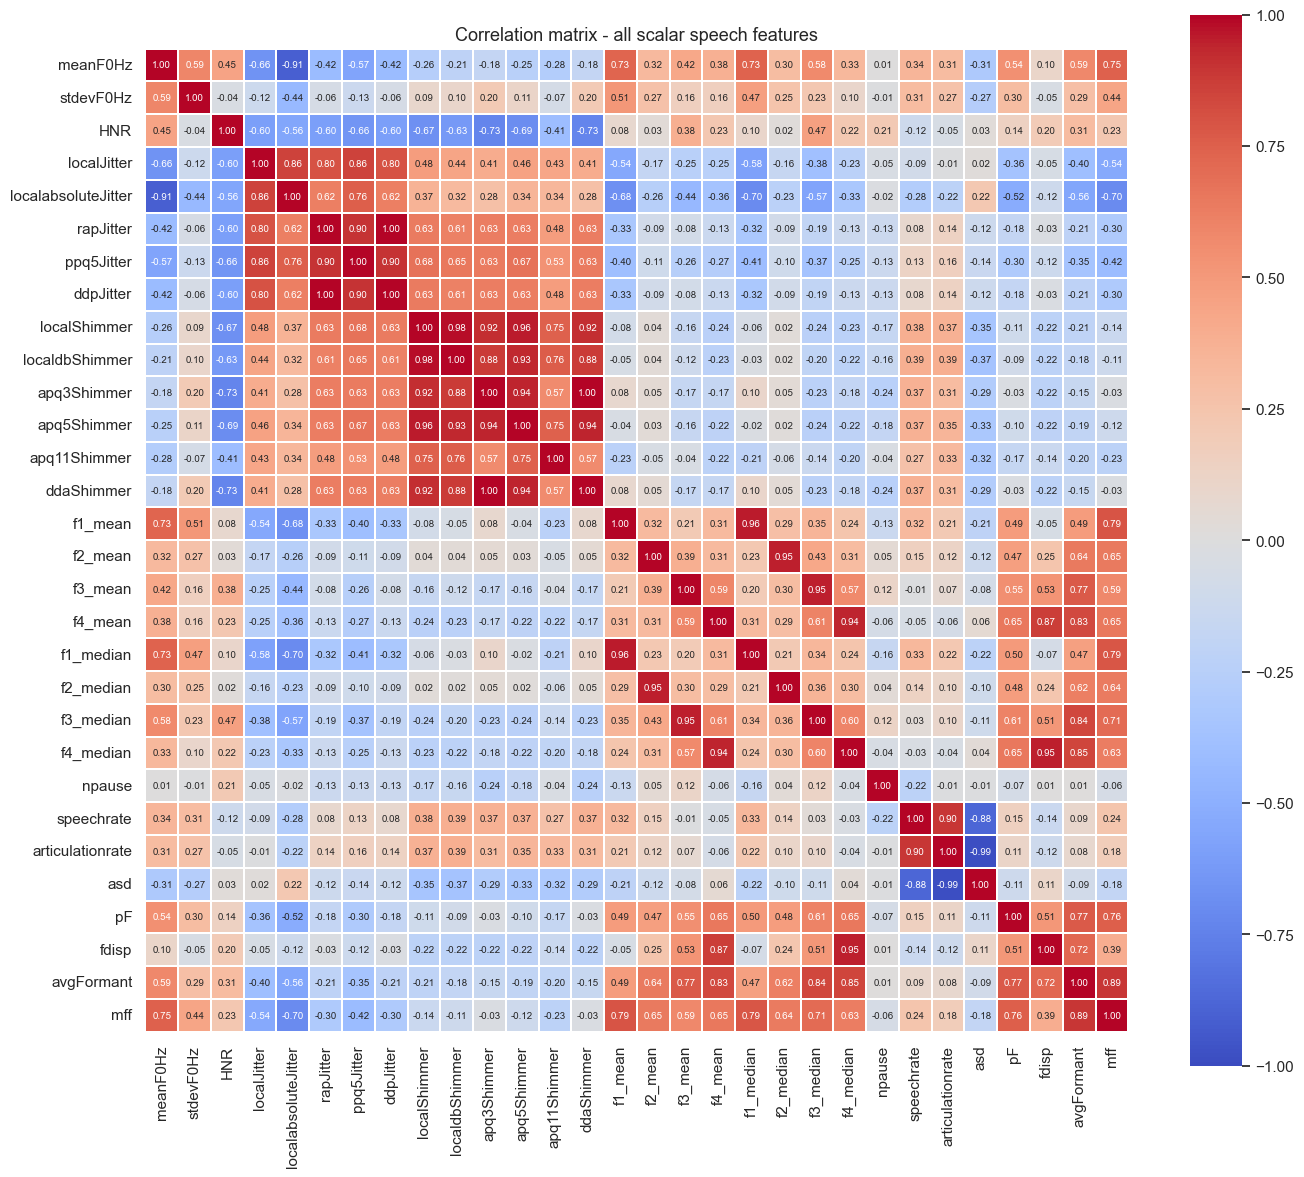

In [69]:
corr = data[scalar_cols].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Correlation matrix - all scalar speech features', fontsize=13)
plt.tight_layout()
plt.show()


In [70]:
corr_vals = corr.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0]

seen = set()
rows = []
for (a, b), v in corr_vals.sort_values(ascending=False).items():
    key = tuple(sorted([a, b]))
    if key not in seen and v > 0.4:
        seen.add(key)
        rows.append({
            'feature_a': a,
            'feature_b': b,
            'correlation': round(corr.loc[a, b], 3)
        })

top_corr_df = pd.DataFrame(rows)
display(top_corr_df)


,feature_a,feature_b,correlation
0,apq3Shimmer,ddaShimmer,1.000
1,asd,articulationrate,-0.986
2,localShimmer,localdbShimmer,0.977
3,localShimmer,apq5Shimmer,0.959
4,f1_median,f1_mean,0.956
...,...,...,...
130,ddpJitter,meanF0Hz,-0.416
131,HNR,apq11Shimmer,-0.412
132,f1_median,ppq5Jitter,-0.408
133,apq3Shimmer,localJitter,0.406


### 2.1 Reduced audio feature set for later plots

Several acoustic variables are near-duplicates of one another. To avoid repeating the same signal,
the next cells keep one representative from the strongly correlated groups and reuse that reduced set
in the single-debate time-evolution plots.


,meanF0Hz,stdevF0Hz,HNR,localJitter,localShimmer,speechrate,npause,f1_mean,f2_mean,fdisp
meanF0Hz,1.000,0.588,0.449,-0.658,-0.265,0.344,0.007,0.733,0.322,0.104
stdevF0Hz,0.588,1.000,-0.035,-0.121,0.089,0.306,-0.014,0.514,0.270,-0.046
HNR,0.449,-0.035,1.000,-0.601,-0.675,-0.116,0.214,0.078,0.034,0.197
localJitter,-0.658,-0.121,-0.601,1.000,0.477,-0.093,-0.045,-0.541,-0.173,-0.050
localShimmer,-0.265,0.089,-0.675,0.477,1.000,0.383,-0.168,-0.079,0.036,-0.219
speechrate,0.344,0.306,-0.116,-0.093,0.383,1.000,-0.223,0.325,0.151,-0.139
npause,0.007,-0.014,0.214,-0.045,-0.168,-0.223,1.000,-0.133,0.052,0.006
f1_mean,0.733,0.514,0.078,-0.541,-0.079,0.325,-0.133,1.000,0.316,-0.053
f2_mean,0.322,0.270,0.034,-0.173,0.036,0.151,0.052,0.316,1.000,0.246
fdisp,0.104,-0.046,0.197,-0.050,-0.219,-0.139,0.006,-0.053,0.246,1.000


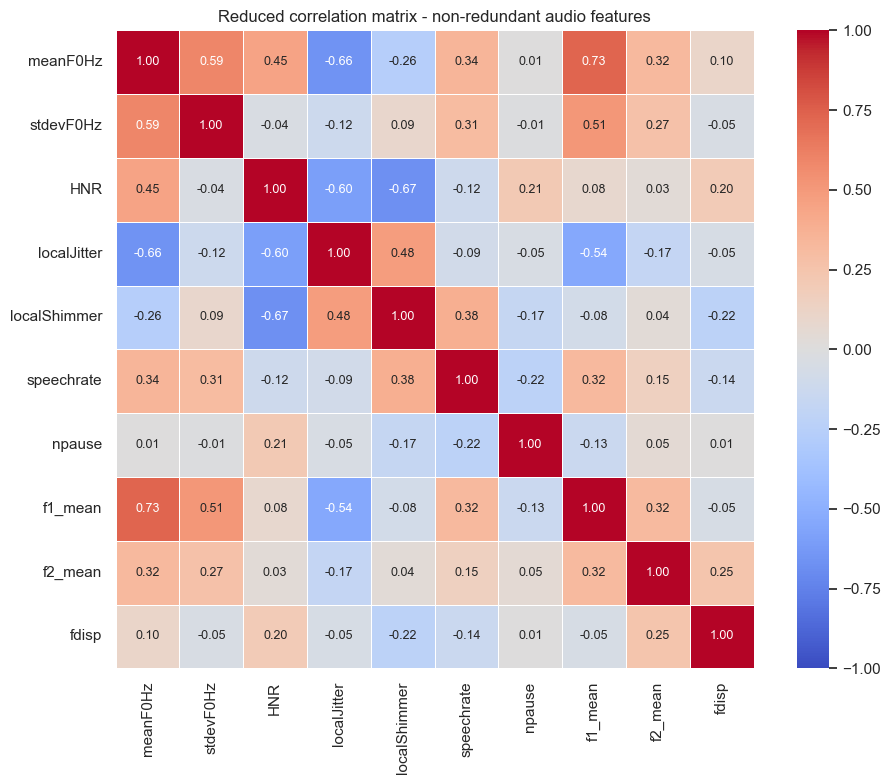

Features kept for later time-series plots:
['meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate']


In [71]:
NON_REDUNDANT = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
]
FEATURES_OVER_TIME = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate'
]

reduced_corr = data[NON_REDUNDANT].corr()
display(reduced_corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    reduced_corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4,
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('Reduced correlation matrix - non-redundant audio features', fontsize=12)
plt.tight_layout()
plt.show()

print('Features kept for later time-series plots:')
print(FEATURES_OVER_TIME)


## 3. Single-debate speaker-cluster case study

For the first presentation, one clean debate is enough to show that the audio embeddings separate
three recurring speaker roles even before speaker identity is assigned. The debate
`Martins_vs_Gouveia_Melo_November_23` is used here only as an unlabeled cluster demonstration.


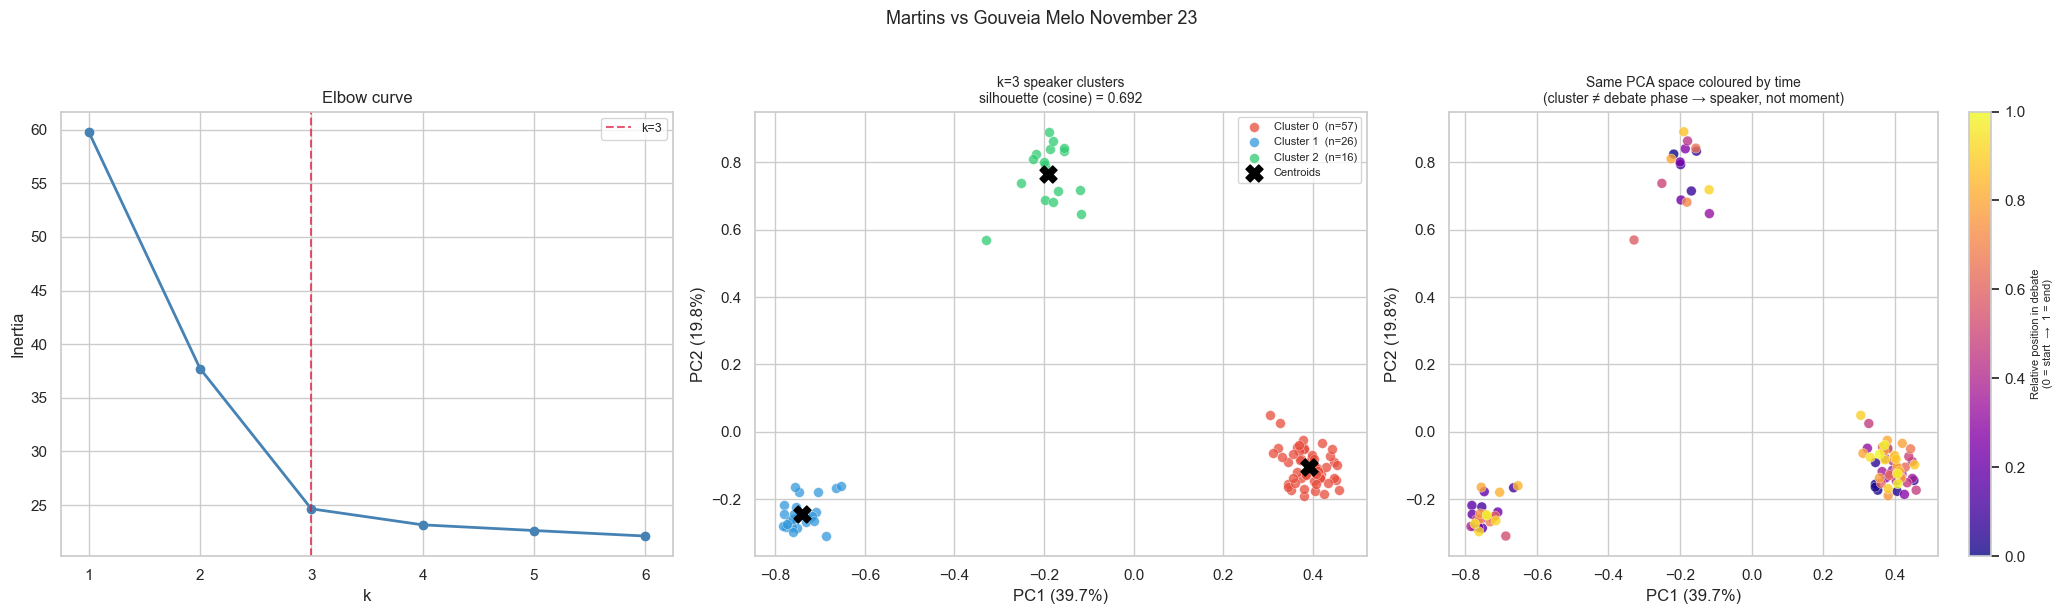

Silhouette score for Martins_vs_Gouveia_Melo_November_23: 0.692


In [72]:
DEMO_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'

demo_dbt = data[data['video'] == DEMO_DEBATE].copy().reset_index(drop=True)
E = np.stack(demo_dbt['speak_embeddings'].values)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

ks = range(1, 7)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E).inertia_ for k in ks]

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = km3.fit_predict(E)
sil = silhouette_score(E, labels_k3, metric='cosine')

demo_dbt['cluster_k3'] = labels_k3
cluster_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

# time normalised to [0,1] within this debate for temporal coloring
demo_sorted = demo_dbt.sort_values('time stamp').reset_index(drop=True)
t_min, t_max = demo_sorted['time stamp'].min(), demo_sorted['time stamp'].max()
t_norm = (demo_sorted['time stamp'] - t_min) / max(t_max - t_min, 1)
E_2d_sorted = pca.transform(np.stack(demo_sorted['speak_embeddings'].values))
centroids_2d = pca.transform(km3.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(DEMO_DEBATE.replace('_', ' '), fontsize=13, y=1.02)

# panel 1: elbow
axes[0].plot(list(ks), inertias, marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=3, color='crimson', linestyle='--', alpha=0.7, label='k=3')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow curve')
axes[0].legend(fontsize=9)

# panel 2: k=3 cluster scatter (larger, silhouette in title)
cluster_palette = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    mask = labels_k3 == i
    axes[1].scatter(
        E_2d[mask, 0], E_2d[mask, 1],
        c=cluster_palette[i], label=f'Cluster {i}  (n={mask.sum()})',
        alpha=0.75, s=50, edgecolors='white', linewidth=0.3
    )
axes[1].scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=150, zorder=5, label='Centroids'
)
axes[1].set_title(f'k=3 speaker clusters\nsilhouette (cosine) = {sil:.3f}', fontsize=10)
axes[1].set_xlabel(f'PC1 ({var1:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}%)')
axes[1].legend(fontsize=8)

# panel 3: same PCA space coloured by temporal position
sc = axes[2].scatter(
    E_2d_sorted[:, 0], E_2d_sorted[:, 1],
    c=t_norm, cmap='plasma',
    alpha=0.8, s=50, edgecolors='white', linewidth=0.3
)
cbar = plt.colorbar(sc, ax=axes[2])
cbar.set_label('Relative position in debate\n(0 = start  →  1 = end)', fontsize=8)
axes[2].set_title('Same PCA space coloured by time\n(cluster ≠ debate phase → speaker, not moment)', fontsize=10)
axes[2].set_xlabel(f'PC1 ({var1:.1f}%)')
axes[2].set_ylabel(f'PC2 ({var2:.1f}%)')

plt.tight_layout()
plt.show()

print(f'Silhouette score for {DEMO_DEBATE}: {sil:.3f}')


### 3.1 Silhouette score for k=3 across all debates

One demo debate is not enough to claim the 3-cluster structure is real. This section computes the
silhouette score for k=3 on every debate and plots them together, so the consistency of the signal
is visible at a glance.

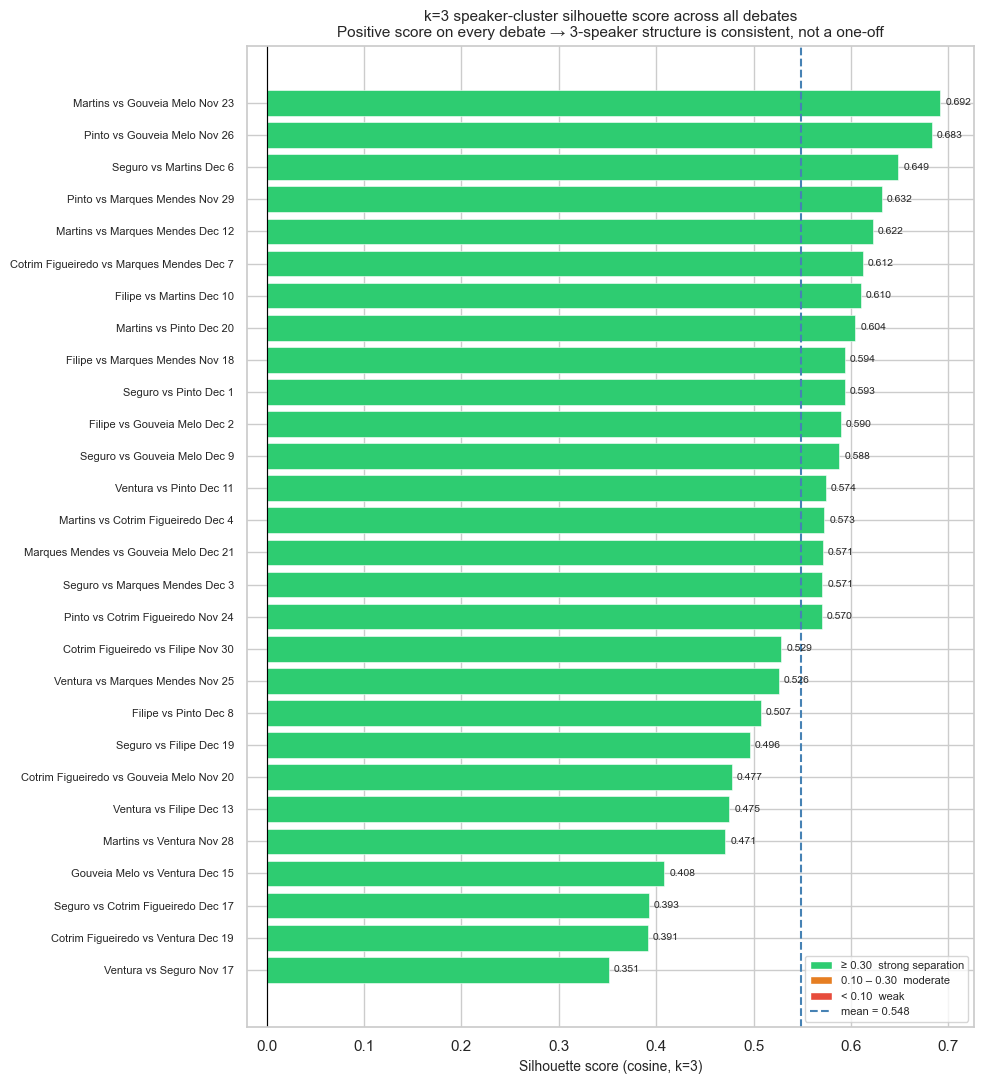

Debates: 28 | mean silhouette: 0.548 | median: 0.572
Strong (≥0.30): 28 | Moderate (0.10–0.30): 0 | Weak (<0.10): 0


In [73]:
sil_rows = []
for video in debate_videos:
    sub = data[data['video'] == video]
    if len(sub) < 4:
        continue
    E_v = np.stack(sub['speak_embeddings'].values)
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbl = km.fit_predict(E_v)
    if len(np.unique(lbl)) < 3:
        continue
    s = silhouette_score(E_v, lbl, metric='cosine')
    sil_rows.append({'debate': video.replace('_vs_', ' vs ').replace('_', ' ')
                                   .replace('November', 'Nov').replace('December', 'Dec'),
                     'silhouette': s,
                     'n_segments': len(sub)})

sil_df = pd.DataFrame(sil_rows).sort_values('silhouette', ascending=True).reset_index(drop=True)

mean_sil = sil_df['silhouette'].mean()
median_sil = sil_df['silhouette'].median()

bar_colors = ['#2ecc71' if s >= 0.3 else '#e67e22' if s >= 0.1 else '#e74c3c'
              for s in sil_df['silhouette']]

fig, ax = plt.subplots(figsize=(10, 11))
bars = ax.barh(sil_df['debate'], sil_df['silhouette'], color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(mean_sil, color='steelblue', linestyle='--', linewidth=1.5, label=f'mean = {mean_sil:.3f}')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, sil_df['silhouette']):
    ax.text(max(val + 0.005, 0.005), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=7.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='≥ 0.30  strong separation'),
    Patch(facecolor='#e67e22', label='0.10 – 0.30  moderate'),
    Patch(facecolor='#e74c3c', label='< 0.10  weak'),
    plt.Line2D([0], [0], color='steelblue', linestyle='--', linewidth=1.5, label=f'mean = {mean_sil:.3f}'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

ax.set_xlabel('Silhouette score (cosine, k=3)', fontsize=10)
ax.set_title('k=3 speaker-cluster silhouette score across all debates\n'
             'Positive score on every debate → 3-speaker structure is consistent, not a one-off', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(left=min(sil_df['silhouette'].min() - 0.05, -0.02))
plt.tight_layout()
plt.show()

print(f'Debates: {len(sil_df)} | mean silhouette: {mean_sil:.3f} | median: {median_sil:.3f}')
print(f'Strong (≥0.30): {(sil_df["silhouette"] >= 0.30).sum()} | '
      f'Moderate (0.10–0.30): {((sil_df["silhouette"] >= 0.10) & (sil_df["silhouette"] < 0.30)).sum()} | '
      f'Weak (<0.10): {(sil_df["silhouette"] < 0.10).sum()}')


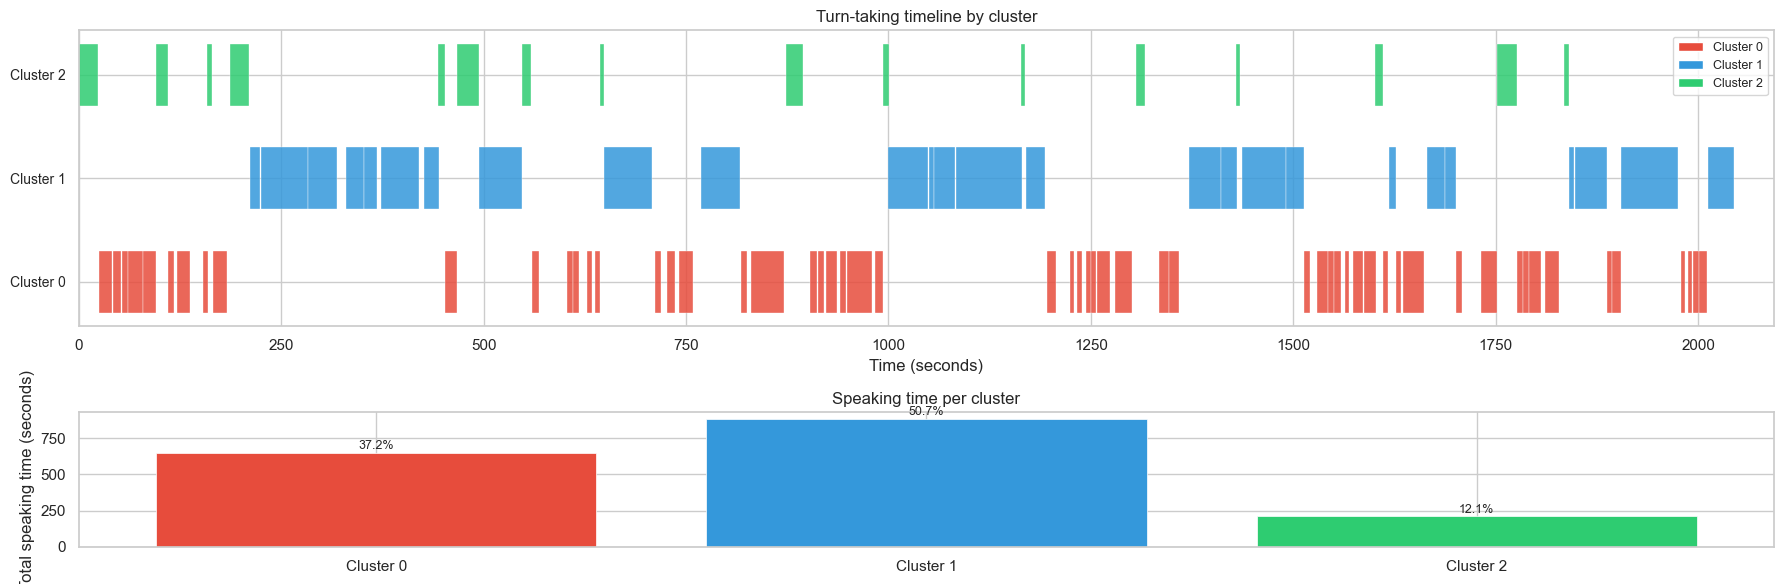

Turn statistics by cluster - Martins_vs_Gouveia_Melo_November_23:
  Cluster 0: 57 segments | mean duration 11.4s | median 8.7s | total 648s
  Cluster 1: 26 segments | mean duration 34.0s | median 29.3s | total 883s
  Cluster 2: 16 segments | mean duration 13.2s | median 10.4s | total 210s


In [74]:
demo_dbt = demo_dbt.sort_values('time stamp').reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(18, 6), gridspec_kw={'height_ratios': [2.2, 1]})

timeline_ax = axes[0]
for _, row in demo_dbt.iterrows():
    c = int(row['cluster_k3'])
    timeline_ax.barh(
        y=c,
        width=row['duration'],
        left=row['time stamp'],
        height=0.6,
        color=cluster_colors[c],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.3
    )

timeline_ax.set_yticks([0, 1, 2])
timeline_ax.set_yticklabels([cluster_labels[i] for i in [0, 1, 2]], fontsize=10)
timeline_ax.set_xlabel('Time (seconds)')
timeline_ax.set_title('Turn-taking timeline by cluster')
timeline_ax.set_xlim(0, demo_dbt['time stamp'].max() + demo_dbt['duration'].max())

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cluster_colors[i], label=cluster_labels[i]) for i in [0, 1, 2]]
timeline_ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

time_per_cluster = demo_dbt.groupby('cluster_k3')['duration'].sum().reindex([0, 1, 2], fill_value=0)
total_time = time_per_cluster.sum()

bar_ax = axes[1]
bars = bar_ax.bar(
    [cluster_labels[i] for i in [0, 1, 2]],
    time_per_cluster.values,
    color=[cluster_colors[i] for i in [0, 1, 2]],
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, time_per_cluster.values):
    pct = 100 * val / max(total_time, 1)
    bar_ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{pct:.1f}%', ha='center', va='bottom', fontsize=9
    )

bar_ax.set_ylabel('Total speaking time (seconds)')
bar_ax.set_title('Speaking time per cluster')

plt.tight_layout()
plt.show()

print(f'Turn statistics by cluster - {DEMO_DEBATE}:')
for c in [0, 1, 2]:
    sub = demo_dbt[demo_dbt['cluster_k3'] == c]
    print(
        f'  Cluster {c}: {len(sub)} segments | '
        f'mean duration {sub["duration"].mean():.1f}s | '
        f'median {sub["duration"].median():.1f}s | '
        f'total {sub["duration"].sum():.0f}s'
    )


### 3.2 Audio features over time by speaker cluster

Two complementary views of the same demo debate:
- **Figure 1** (shared x-axis): cluster Gantt on top + scatter dots for each audio feature below — lets you directly compare *who is speaking* with *what their voice sounds like* at the same moment in time.
- **Figure 2** (violin plots): marginal distribution of each feature per cluster — shows the full spread and median, independent of when segments occur.

C:\Users\dinis\AppData\Local\Temp\ipykernel_996\1588285704.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


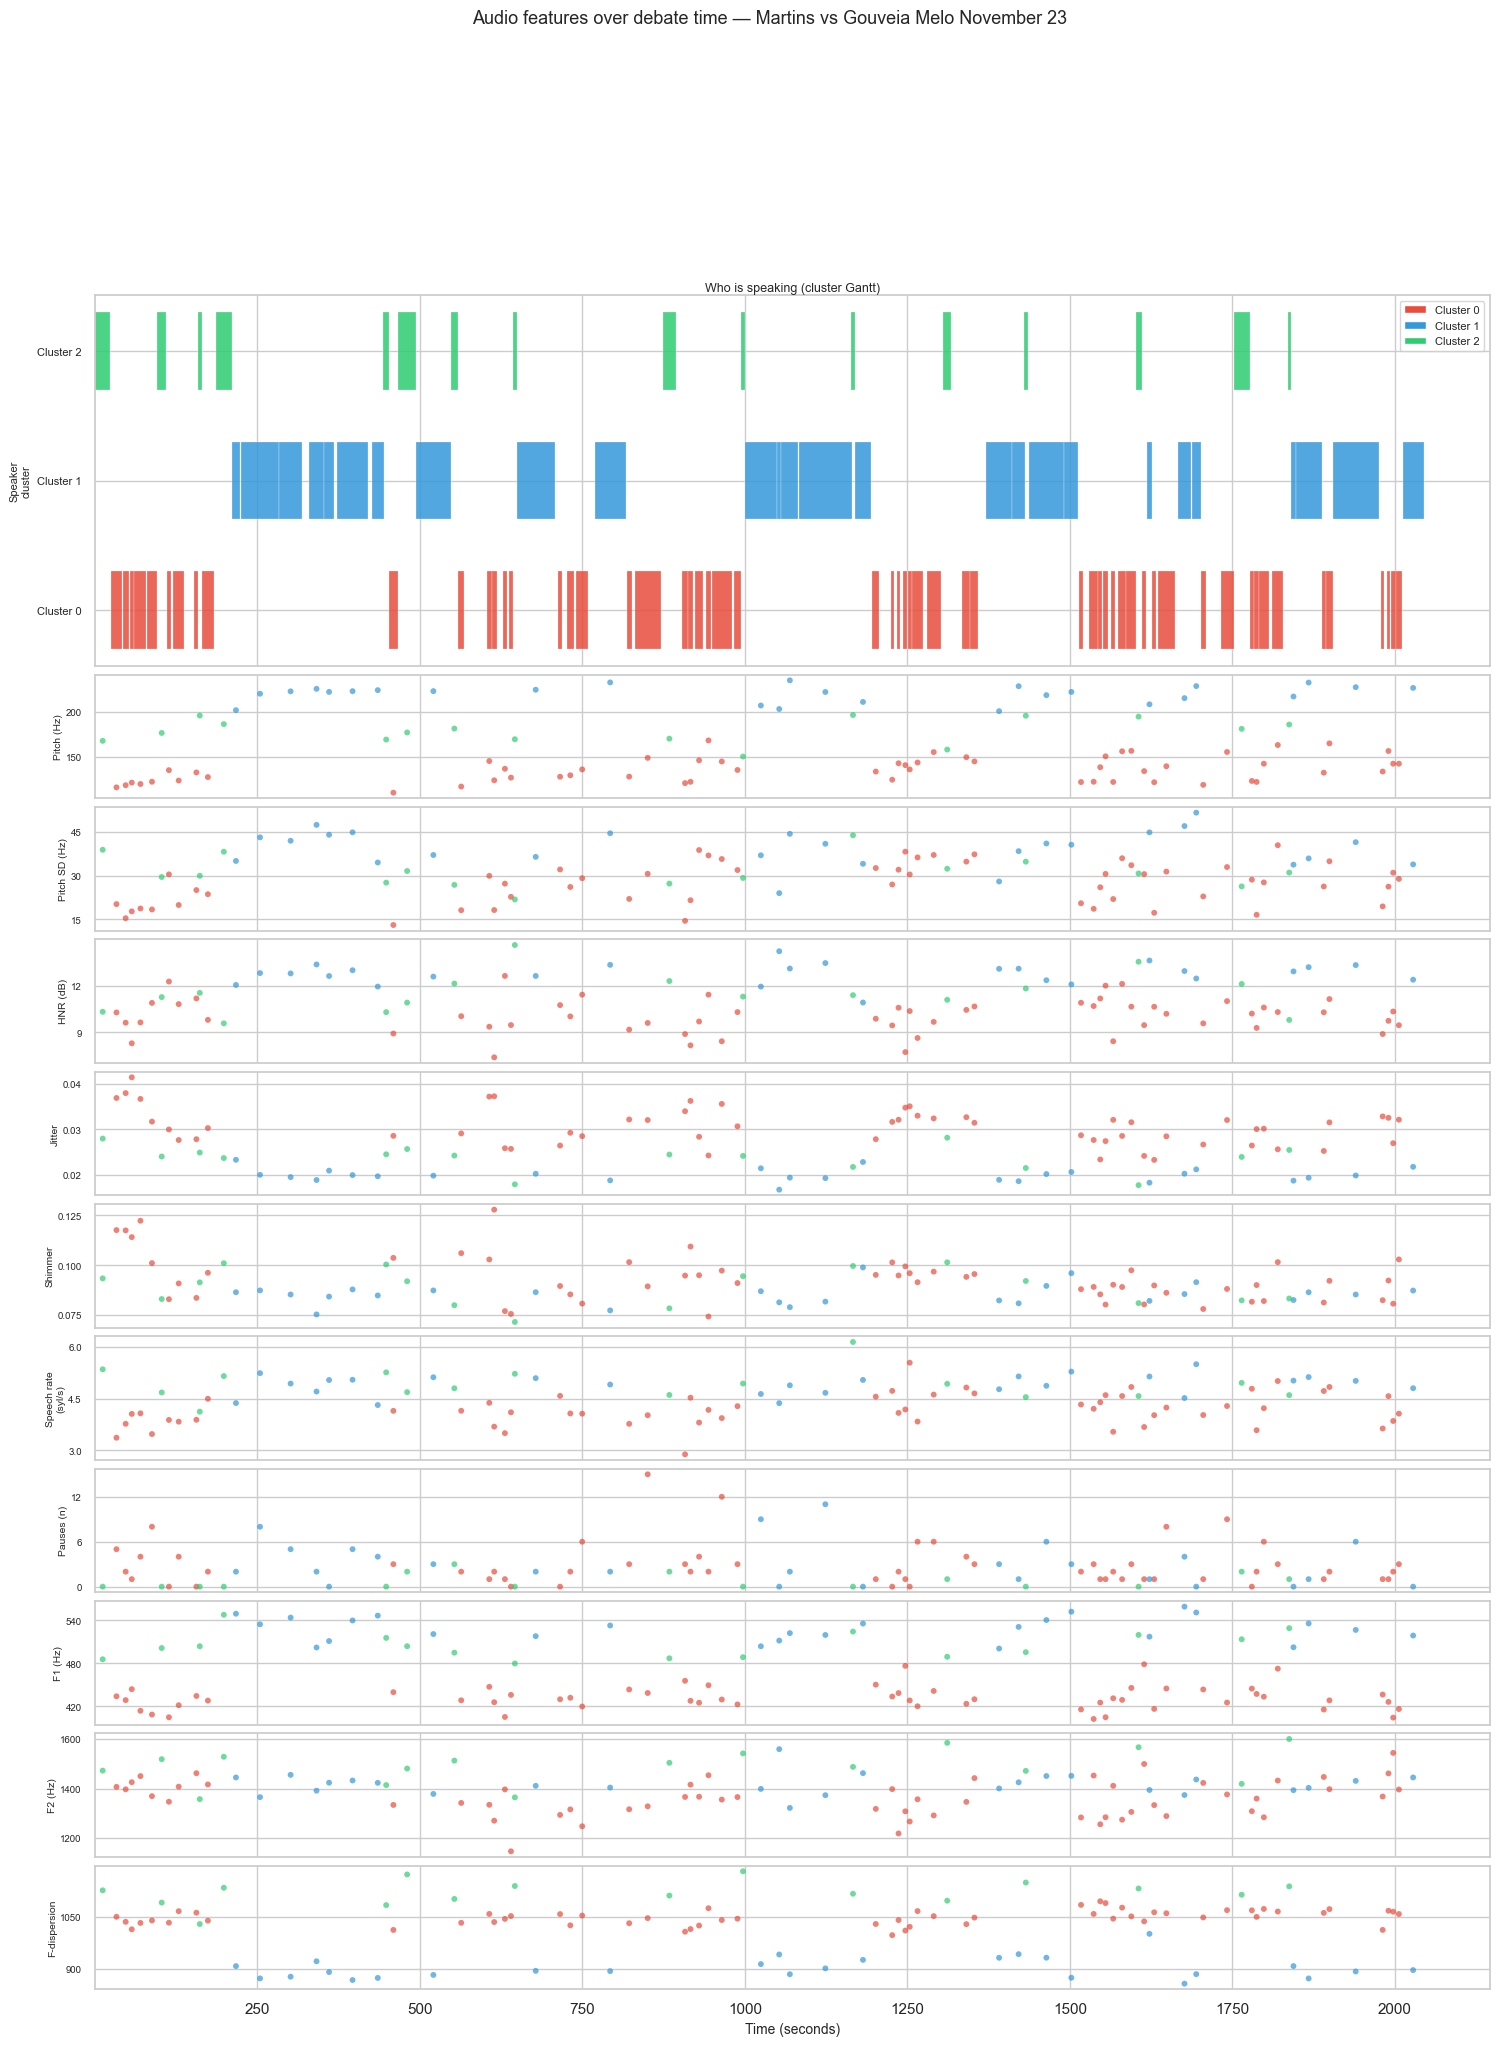

In [75]:
# ── Figure 1: shared x-axis — cluster Gantt + all non-redundant features ──────
FEATURES_TIMELINE = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
]
FEATURE_LABELS = {
    'meanF0Hz':    'Pitch (Hz)',
    'stdevF0Hz':   'Pitch SD (Hz)',
    'HNR':         'HNR (dB)',
    'localJitter': 'Jitter',
    'localShimmer':'Shimmer',
    'speechrate':  'Speech rate\n(syl/s)',
    'npause':      'Pauses (n)',
    'f1_mean':     'F1 (Hz)',
    'f2_mean':     'F2 (Hz)',
    'fdisp':       'F-dispersion',
}

demo_timeline = demo_dbt.sort_values('time stamp').reset_index(drop=True)
demo_timeline['seg_mid'] = demo_timeline['time stamp'] + demo_timeline['duration'] / 2

n_feats = len(FEATURES_TIMELINE)
height_ratios = [3] + [1] * n_feats

fig, axes = plt.subplots(
    n_feats + 1, 1,
    figsize=(18, 4 + n_feats * 1.8),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.06}
)
fig.suptitle(
    f'Audio features over debate time — {DEMO_DEBATE.replace("_", " ")}',
    fontsize=13, y=1.01
)

# row 0: cluster Gantt
for _, row in demo_timeline.iterrows():
    c = int(row['cluster_k3'])
    axes[0].barh(
        y=c, width=row['duration'], left=row['time stamp'],
        height=0.6, color=cluster_colors[c], alpha=0.85,
        edgecolor='white', linewidth=0.2
    )
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels([cluster_labels[i] for i in [0, 1, 2]], fontsize=8)
axes[0].set_ylabel('Speaker\ncluster', fontsize=8)
axes[0].set_title('Who is speaking (cluster Gantt)', fontsize=9, pad=3)
from matplotlib.patches import Patch as _P
axes[0].legend(
    handles=[_P(facecolor=cluster_colors[i], label=cluster_labels[i]) for i in [0, 1, 2]],
    loc='upper right', fontsize=8
)

# rows 1‥n: scatter dots per feature, colored by cluster
for ax_idx, feat in enumerate(FEATURES_TIMELINE, start=1):
    ax = axes[ax_idx]
    for c in [0, 1, 2]:
        mask = demo_timeline['cluster_k3'] == c
        ax.scatter(
            demo_timeline.loc[mask, 'seg_mid'],
            demo_timeline.loc[mask, feat],
            c=cluster_colors[c], s=18, alpha=0.70, edgecolors='none'
        )
    ax.set_ylabel(FEATURE_LABELS.get(feat, feat), fontsize=7.5, labelpad=2)
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    ax.tick_params(axis='y', labelsize=7)

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.show()


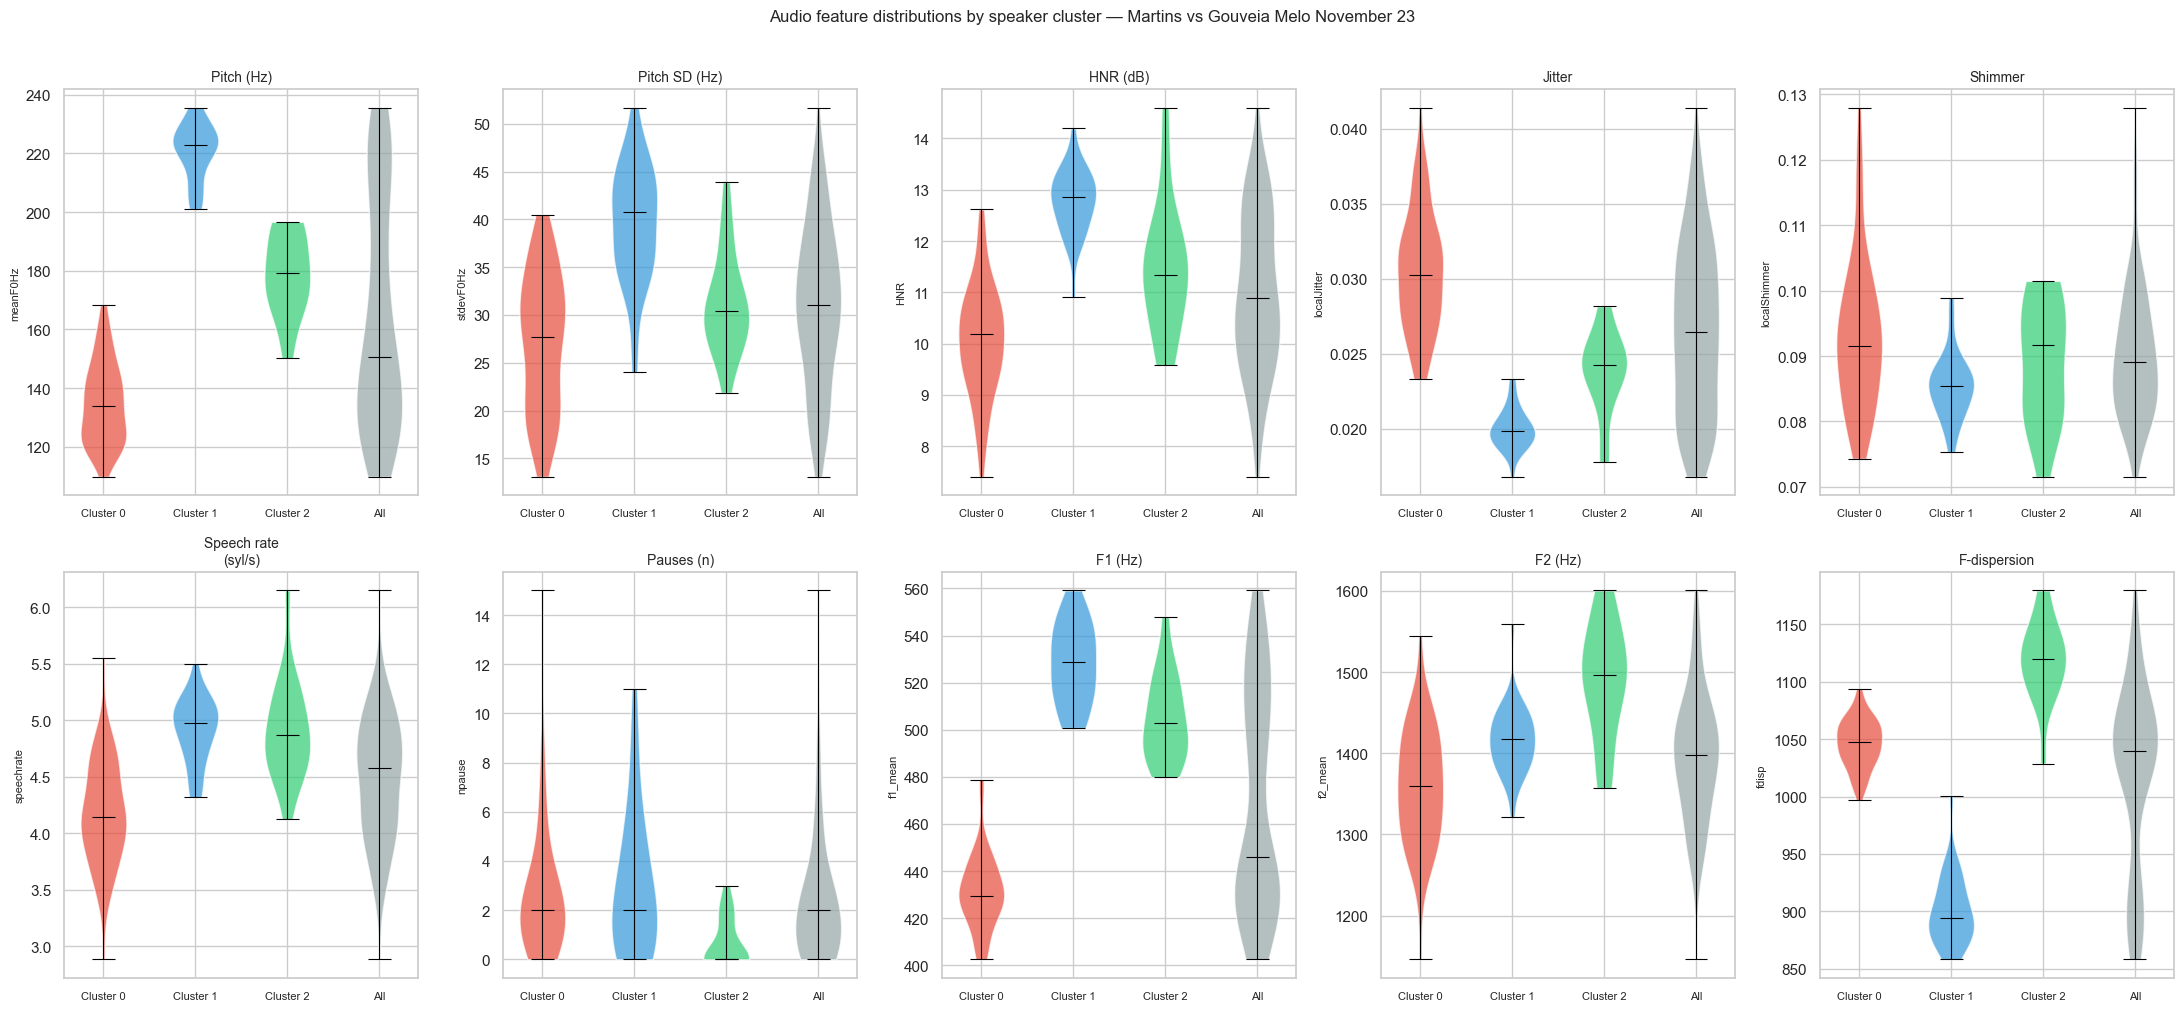

In [76]:
# ── Figure 2: violin plots — all non-redundant features, 4 violins each ───────
# Positions: 0=Cluster 0, 1=Cluster 1, 2=Cluster 2, 3=All (global)
violin_colors = [cluster_colors[0], cluster_colors[1], cluster_colors[2], '#95a5a6']
x_labels = [cluster_labels[i] for i in [0, 1, 2]] + ['All']

ncols = 5
nrows = math.ceil(len(FEATURES_TIMELINE) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5 * nrows))
fig.suptitle(
    f'Audio feature distributions by speaker cluster — {DEMO_DEBATE.replace("_", " ")}',
    fontsize=12, y=1.01
)
axes = axes.flatten()

for ax_idx, feat in enumerate(FEATURES_TIMELINE):
    ax = axes[ax_idx]
    groups = [
        demo_dbt.loc[demo_dbt['cluster_k3'] == c, feat].dropna().values
        for c in [0, 1, 2]
    ] + [demo_dbt[feat].dropna().values]

    parts = ax.violinplot(groups, positions=[0, 1, 2, 3], showmedians=True, showextrema=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(violin_colors[i])
        pc.set_alpha(0.70)
    for part_name in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        parts[part_name].set_edgecolor('black')
        parts[part_name].set_linewidth(0.8)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=10)
    ax.set_ylabel(feat, fontsize=8)

for ax_idx in range(len(FEATURES_TIMELINE), len(axes)):
    axes[ax_idx].axis('off')

plt.tight_layout()
plt.show()


## 4. Transcript text statistics

Word count per segment:
count    1407.00
mean      128.26
std        86.08
min        18.00
25%        75.00
50%       100.00
75%       147.00
max       712.00
Name: word_count, dtype: float64

Words per second:
count    1407.000
mean        3.110
std         0.580
min         0.694
25%         2.691
50%         3.064
75%         3.507
max         5.337
Name: words_per_sec, dtype: float64

Missing transcripts: 0


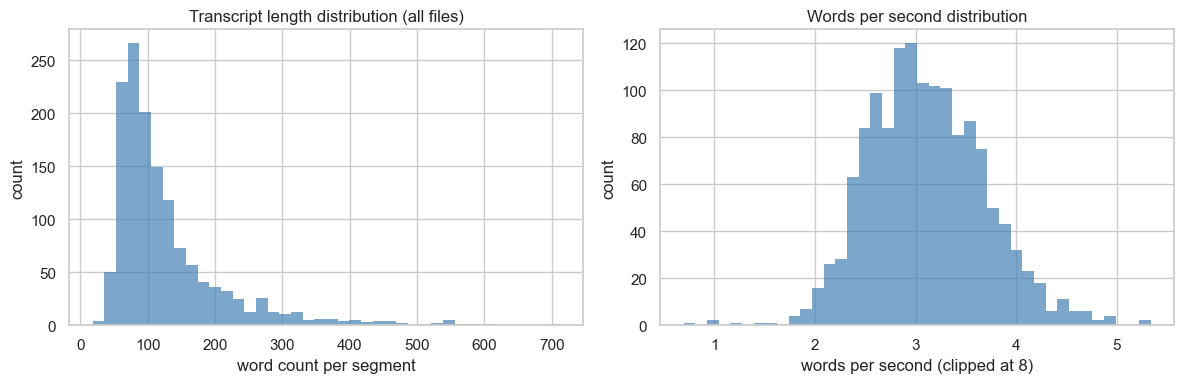

In [77]:
print('Word count per segment:')
print(data_speech['word_count'].describe().round(2))
print()
print('Words per second:')
print(data_speech['words_per_sec'].describe().round(3))
print()
print(f'Missing transcripts: {data_speech["transcript"].isnull().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data_speech['word_count'], bins=40, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].set_xlabel('word count per segment')
axes[0].set_ylabel('count')
axes[0].set_title('Transcript length distribution (all files)')

axes[1].hist(data_speech['words_per_sec'].clip(0, 8), bins=40, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].set_xlabel('words per second (clipped at 8)')
axes[1].set_ylabel('count')
axes[1].set_title('Words per second distribution')

plt.tight_layout()
plt.show()

## 5. Word clouds

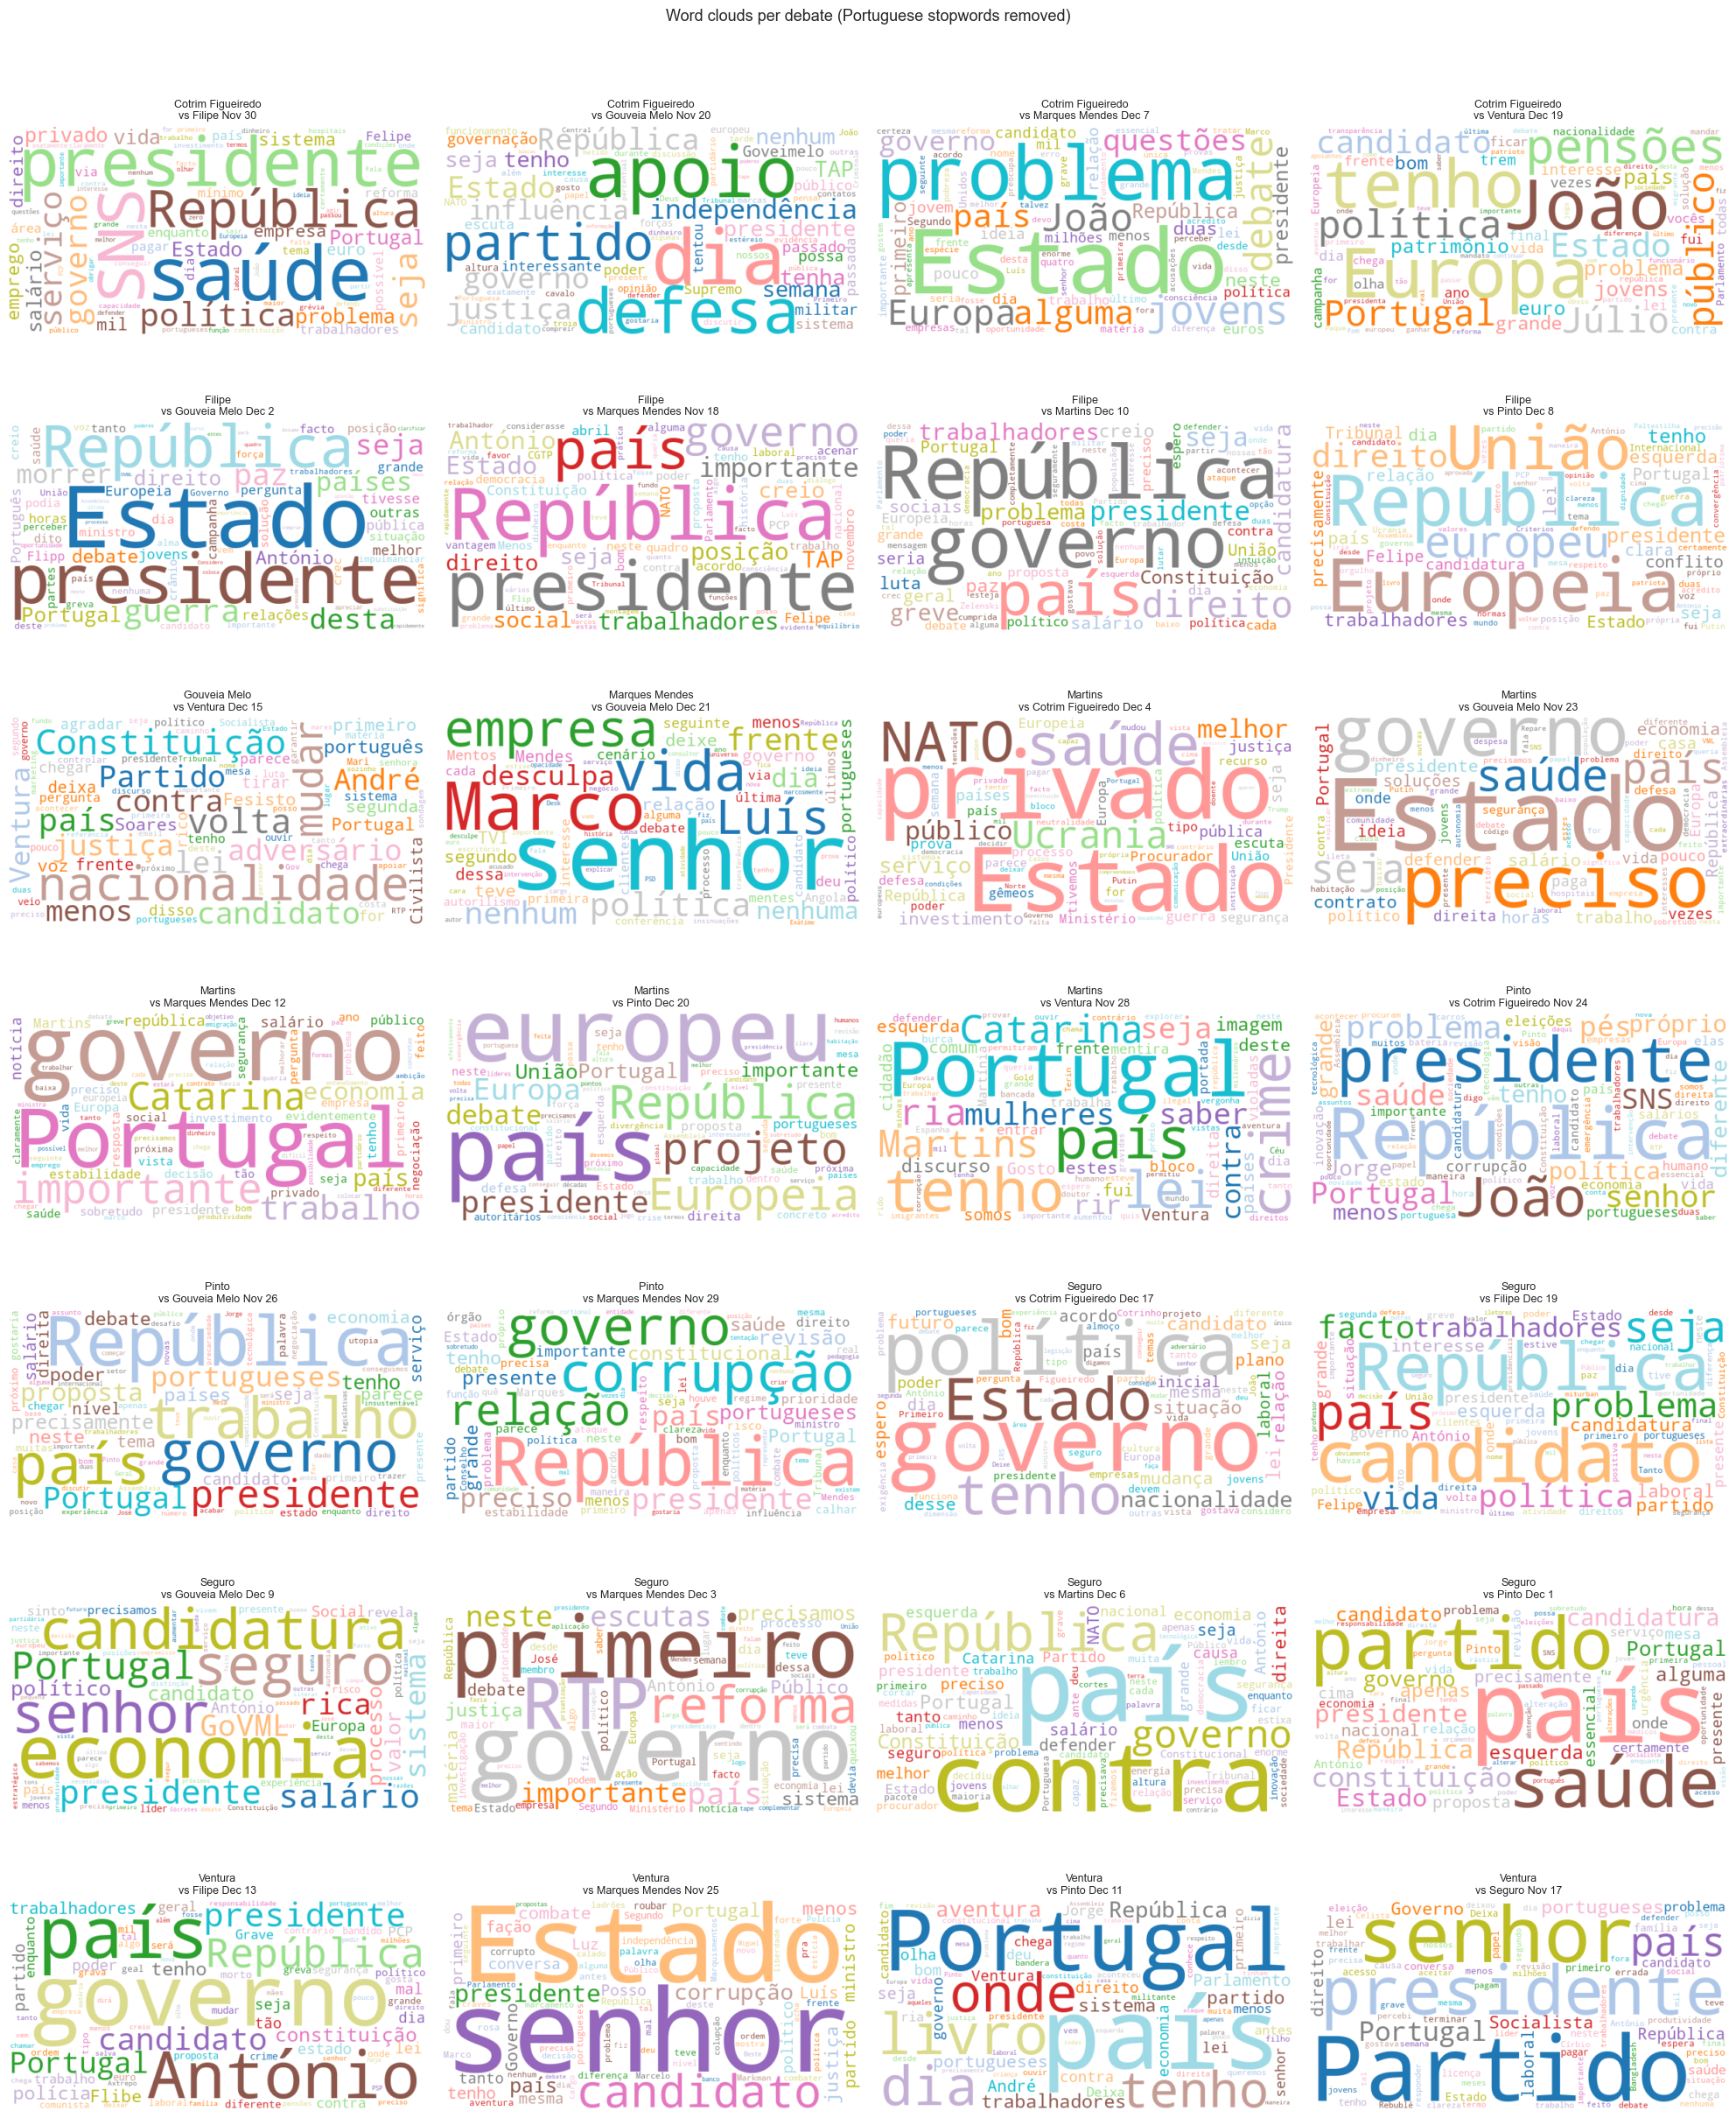

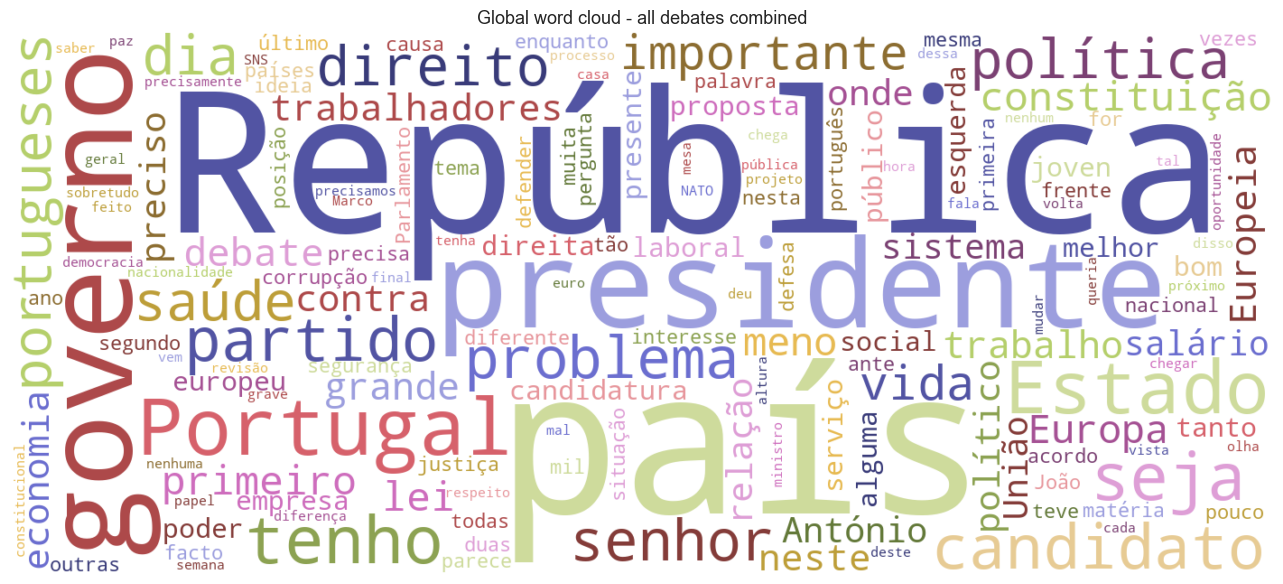

In [78]:
def make_wordcloud(text, title, ax):
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        stopwords=PT_STOPWORDS,
        max_words=80,
        colormap='tab20',
        min_word_length=3,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

n = len(debate_videos)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, video_name in enumerate(sorted(debate_videos)):
    sub = speech_debates[speech_debates['video'] == video_name]
    full_text = ' '.join(sub['transcript'].dropna().astype(str).tolist())
    title = video_name.replace('_', ' ').replace(' vs ', '\nvs ').replace('November', 'Nov').replace('December', 'Dec')
    make_wordcloud(full_text, title, axes[i])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Word clouds per debate (Portuguese stopwords removed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

all_text = ' '.join(speech_debates['transcript'].dropna().astype(str).tolist())

fig, ax = plt.subplots(figsize=(14, 6))
wc_global = WordCloud(
    width=1400, height=600,
    background_color='white',
    stopwords=PT_STOPWORDS,
    max_words=150,
    colormap='tab20b',
    min_word_length=3,
    collocations=False
).generate(all_text)

ax.imshow(wc_global, interpolation='bilinear')
ax.axis('off')
ax.set_title('Global word cloud - all debates combined', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Bigrams  

Global token total used for bigrams: 45071


,bigram,count,per_1000_tokens
0,presidente república,144,3.19
1,união europeia,82,1.82
2,partido socialista,37,0.82
3,primeiro ministro,36,0.80
4,presente república,36,0.80
5,assembleia república,31,0.69
6,andré ventura,29,0.64
7,cima mesa,26,0.58
8,catarina martins,26,0.58
9,segunda volta,25,0.55


,video,n_tokens,bigram,count,per_1000_tokens
0,Cotrim_Figueiredo_vs_Filipe_November_30,1924,presidente república,9,4.68
1,Cotrim_Figueiredo_vs_Filipe_November_30,1924,sair euro,4,2.08
2,Cotrim_Figueiredo_vs_Filipe_November_30,1924,antonio felipe,3,1.56
3,Cotrim_Figueiredo_vs_Filipe_November_30,1924,união europeia,3,1.56
4,Cotrim_Figueiredo_vs_Filipe_November_30,1924,serviço social,3,1.56
5,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,semana passada,3,4.18
6,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,passado partidário,2,2.79
7,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,estéreio influência,2,2.79
8,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,primeiro ministro,2,2.79
9,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,tentou tentou,2,2.79


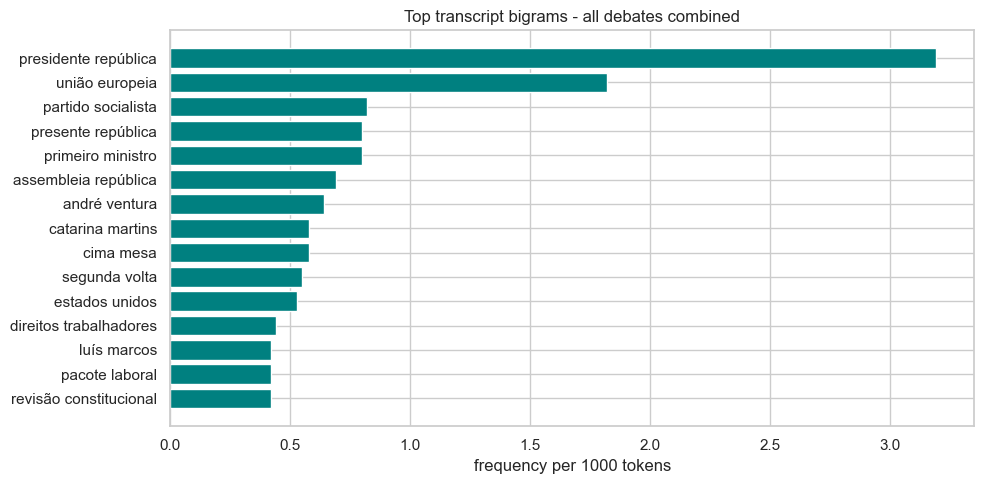

In [79]:
transcript_eda = speech_debates.copy()
transcript_eda['tokens_eda'] = transcript_eda['transcript'].apply(
    lambda t: tokenize_transcript(t, stopwords=PT_STOPWORDS, min_len=3)
)

def top_bigrams_for_group(token_lists, top_n=10):
    counter = Counter()
    total_tokens = 0
    for tokens in token_lists:
        total_tokens += len(tokens)
        counter.update(zip(tokens, tokens[1:]))
    rows = []
    for bg, count in counter.most_common(top_n):
        rows.append({
            'bigram': ' '.join(bg),
            'count': count,
            'per_1000_tokens': round(1000 * count / max(total_tokens, 1), 2)
        })
    return pd.DataFrame(rows), total_tokens

global_bigram_df, global_token_total = top_bigrams_for_group(transcript_eda['tokens_eda'], top_n=15)
print(f'Global token total used for bigrams: {global_token_total}')
display(global_bigram_df)

debate_bigram_rows = []
for video, sub in transcript_eda.groupby('video'):
    tbl, total_tokens = top_bigrams_for_group(sub['tokens_eda'], top_n=5)
    if not tbl.empty:
        tmp = tbl.copy()
        tmp.insert(0, 'video', video)
        tmp.insert(1, 'n_tokens', total_tokens)
        debate_bigram_rows.append(tmp)

debate_bigram_df = pd.concat(debate_bigram_rows, ignore_index=True)
display(debate_bigram_df.head(50))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = global_bigram_df.sort_values('per_1000_tokens', ascending=True)
ax.barh(plot_df['bigram'], plot_df['per_1000_tokens'], color='teal', edgecolor='white')
ax.set_title('Top transcript bigrams - all debates combined')
ax.set_xlabel('frequency per 1000 tokens')
plt.tight_layout()
plt.show()

## 8. Lexical Richness


,video,segments,tokens,unique_tokens,type_token_ratio,root_ttr,repetition_ratio,hapax_ratio,mean_words_per_segment
0,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,33,2029,1248,0.6151,27.7060,0.3849,0.4421,156.5152
1,Ventura_vs_Filipe_December_13,32,2343,1337,0.5706,27.6214,0.4294,0.3965,194.9688
2,Ventura_vs_Pinto_December_11,35,2678,1415,0.5284,27.3433,0.4716,0.3532,211.1143
3,Cotrim_Figueiredo_vs_Filipe_November_30,33,1924,1188,0.6175,27.0841,0.3825,0.4517,149.3030
4,Cotrim_Figueiredo_vs_Ventura_December_19,37,2081,1229,0.5906,26.9411,0.4094,0.4181,157.7838
5,Seguro_vs_Filipe_December_19,36,2006,1179,0.5877,26.3238,0.4123,0.4172,139.6667
6,Pinto_vs_Cotrim_Figueiredo_November_24,32,1633,1063,0.6509,26.3051,0.3491,0.4825,130.8125
7,Seguro_vs_Pinto_December_1,36,1898,1144,0.6027,26.2590,0.3973,0.4215,132.3889
8,Ventura_vs_Marques_Mendes_November_25,32,2226,1222,0.5490,25.9005,0.4510,0.3742,193.5625
9,Seguro_vs_Cotrim_Figueiredo_December_17,28,1395,939,0.6731,25.1408,0.3269,0.4982,125.4643


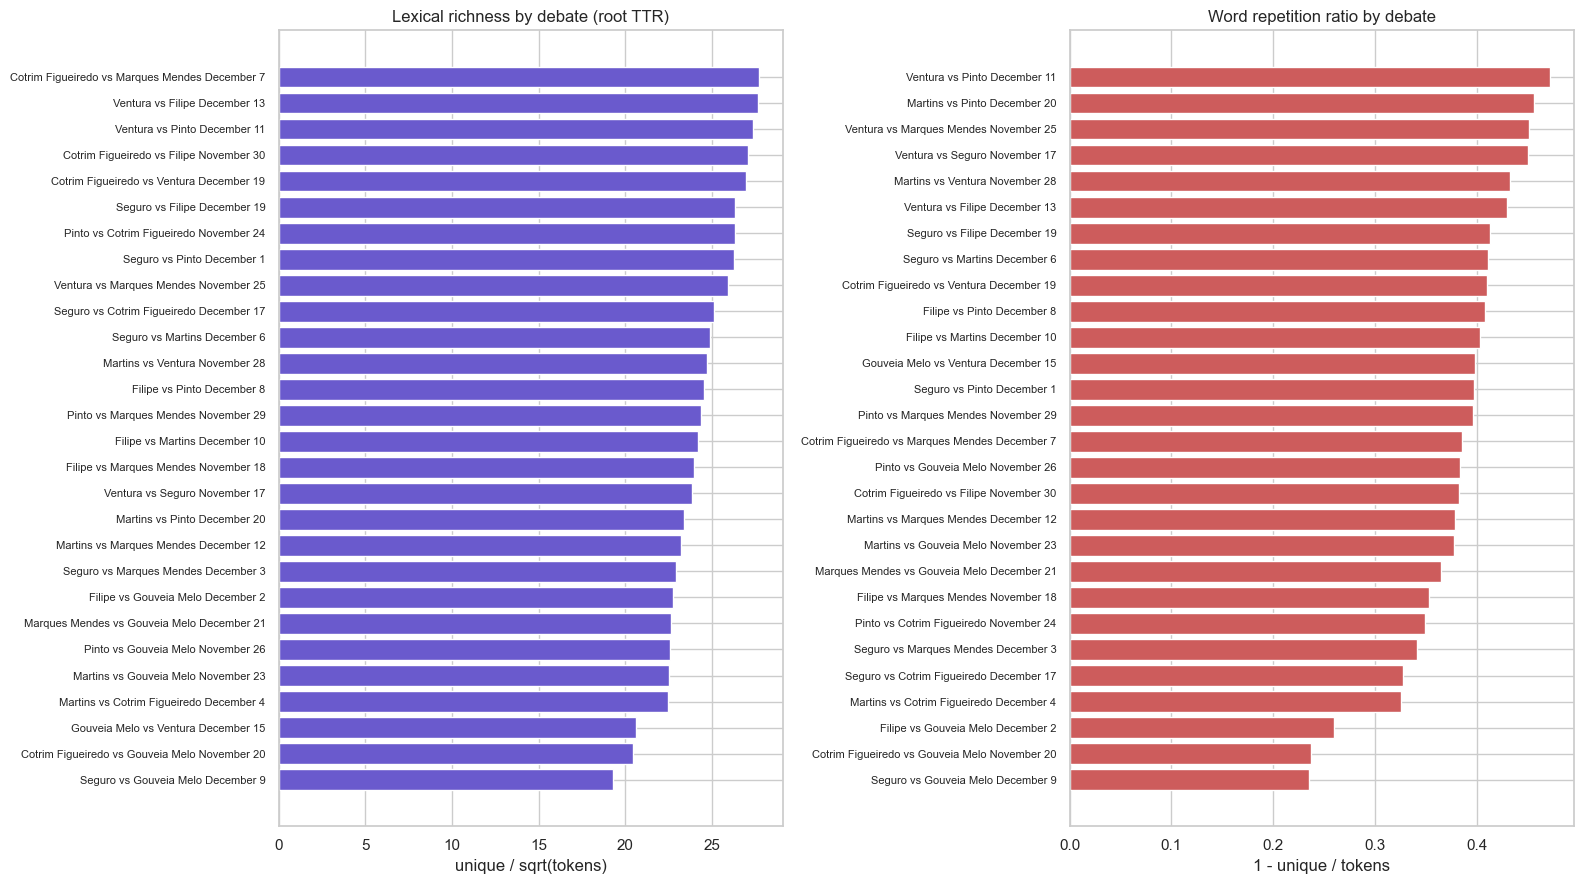

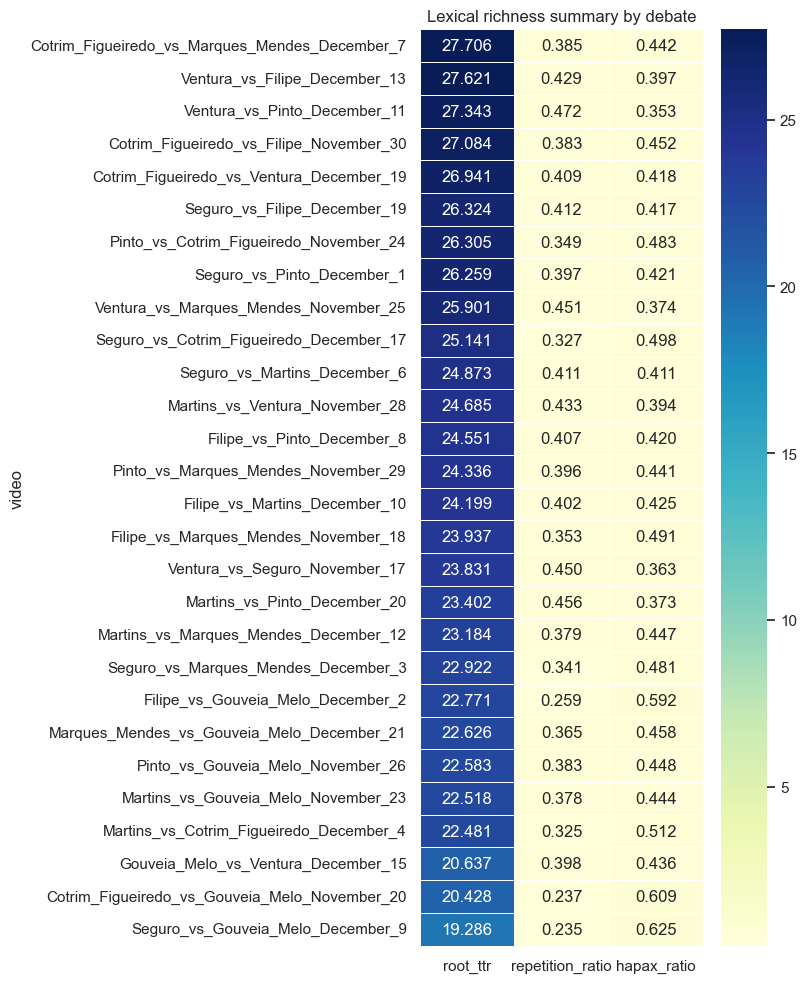

In [80]:
lexical_rows = []

for video, sub in transcript_eda.groupby('video'):
    tokens = [tok for toks in sub['tokens_eda'] for tok in toks]
    counts = Counter(tokens)
    total_tokens = len(tokens)
    unique_tokens = len(counts)
    hapax_count = sum(1 for c in counts.values() if c == 1)

    lexical_rows.append({
        'video': video,
        'segments': len(sub),
        'tokens': total_tokens,
        'unique_tokens': unique_tokens,
        'type_token_ratio': unique_tokens / max(total_tokens, 1),
        'root_ttr': unique_tokens / np.sqrt(max(total_tokens, 1)),
        'repetition_ratio': 1 - (unique_tokens / max(total_tokens, 1)),
        'hapax_ratio': hapax_count / max(total_tokens, 1),
        'mean_words_per_segment': sub['word_count'].mean()
    })

lexical_df = pd.DataFrame(lexical_rows).sort_values('root_ttr', ascending=False).reset_index(drop=True)
display(lexical_df.round(4))

lexical_plot = lexical_df.set_index('video')[['root_ttr', 'repetition_ratio', 'hapax_ratio']]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

root_plot = lexical_df.sort_values('root_ttr', ascending=True)
axes[0].barh(root_plot['video'].str.replace('_', ' '), root_plot['root_ttr'], color='slateblue')
axes[0].set_title('Lexical richness by debate (root TTR)')
axes[0].set_xlabel('unique / sqrt(tokens)')
axes[0].tick_params(axis='y', labelsize=8)

rep_plot = lexical_df.sort_values('repetition_ratio', ascending=True)
axes[1].barh(rep_plot['video'].str.replace('_', ' '), rep_plot['repetition_ratio'], color='indianred')
axes[1].set_title('Word repetition ratio by debate')
axes[1].set_xlabel('1 - unique / tokens')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    lexical_plot,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Lexical richness summary by debate')
plt.tight_layout()
plt.show()


## 9. Debate-level transcript embedding similarity

The `text_embedding` vectors encode what was said. Here, each debate is summarized by its mean
transcript embedding, and cosine distance between debate centroids gives a global view of topical
similarity across debates.


Debate ordering and ideology labels:


,video,candidate_a,candidate_b,party_a,party_b,debate_ideology,ideology_score,segments
0,Filipe_vs_Martins_December_10,Filipe,Martins,CDU,BE,left,-1.0,36
1,Filipe_vs_Pinto_December_8,Filipe,Pinto,CDU,L,left,-1.0,29
2,Filipe_vs_Gouveia_Melo_December_2,Filipe,Gouveia_Melo,CDU,Independent,mix,-0.5,21
3,Filipe_vs_Marques_Mendes_November_18,Filipe,Marques_Mendes,CDU,PSD+CDS,mix,0.0,33
4,Martins_vs_Pinto_December_20,Martins,Pinto,BE,L,left,-1.0,24
5,Martins_vs_Gouveia_Melo_November_23,Martins,Gouveia_Melo,BE,Independent,mix,-0.5,28
6,Martins_vs_Cotrim_Figueiredo_December_4,Martins,Cotrim_Figueiredo,BE,IL,mix,0.0,26
7,Martins_vs_Marques_Mendes_December_12,Martins,Marques_Mendes,BE,PSD+CDS,mix,0.0,33
8,Martins_vs_Ventura_November_28,Martins,Ventura,BE,CH,mix,0.0,33
9,Pinto_vs_Gouveia_Melo_November_26,Pinto,Gouveia_Melo,L,Independent,mix,-0.5,24


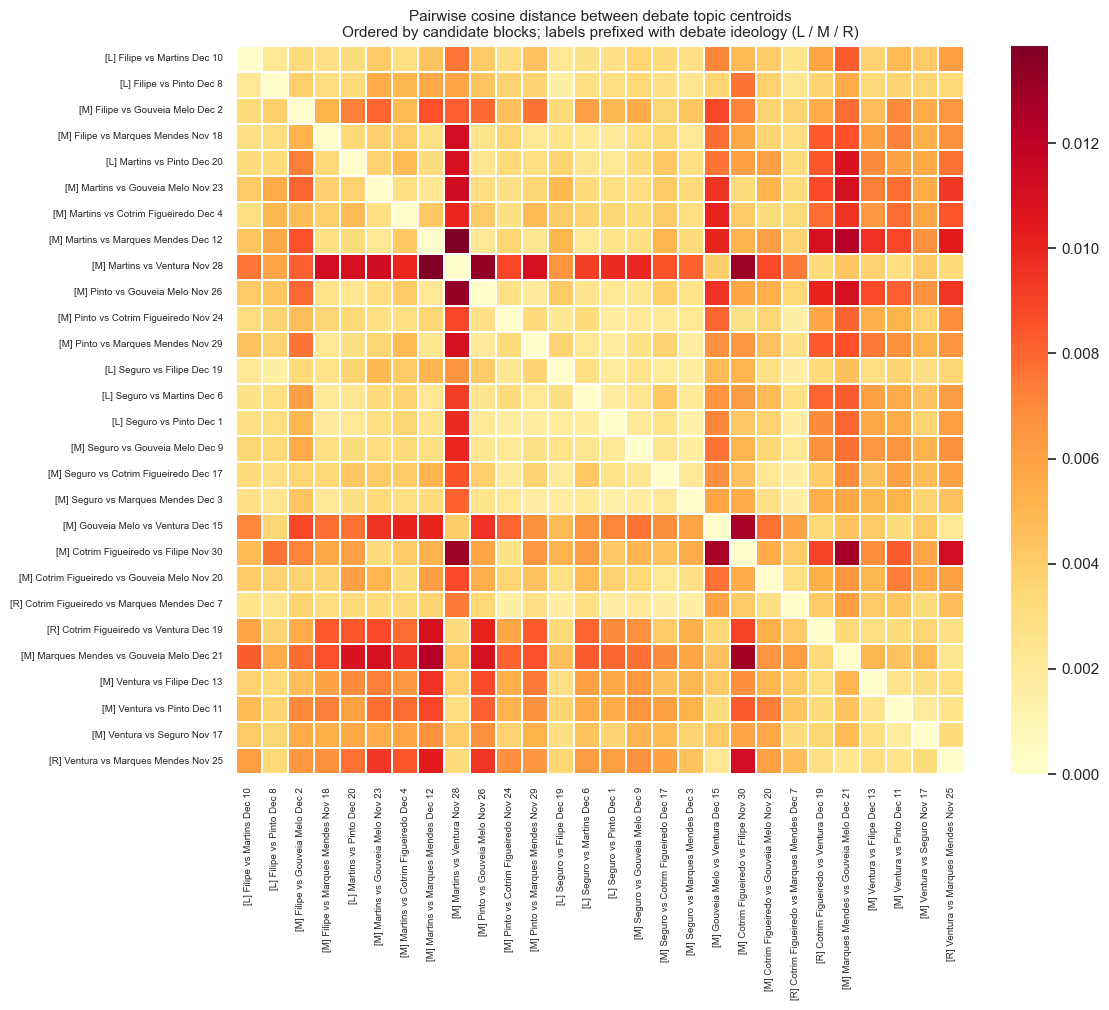

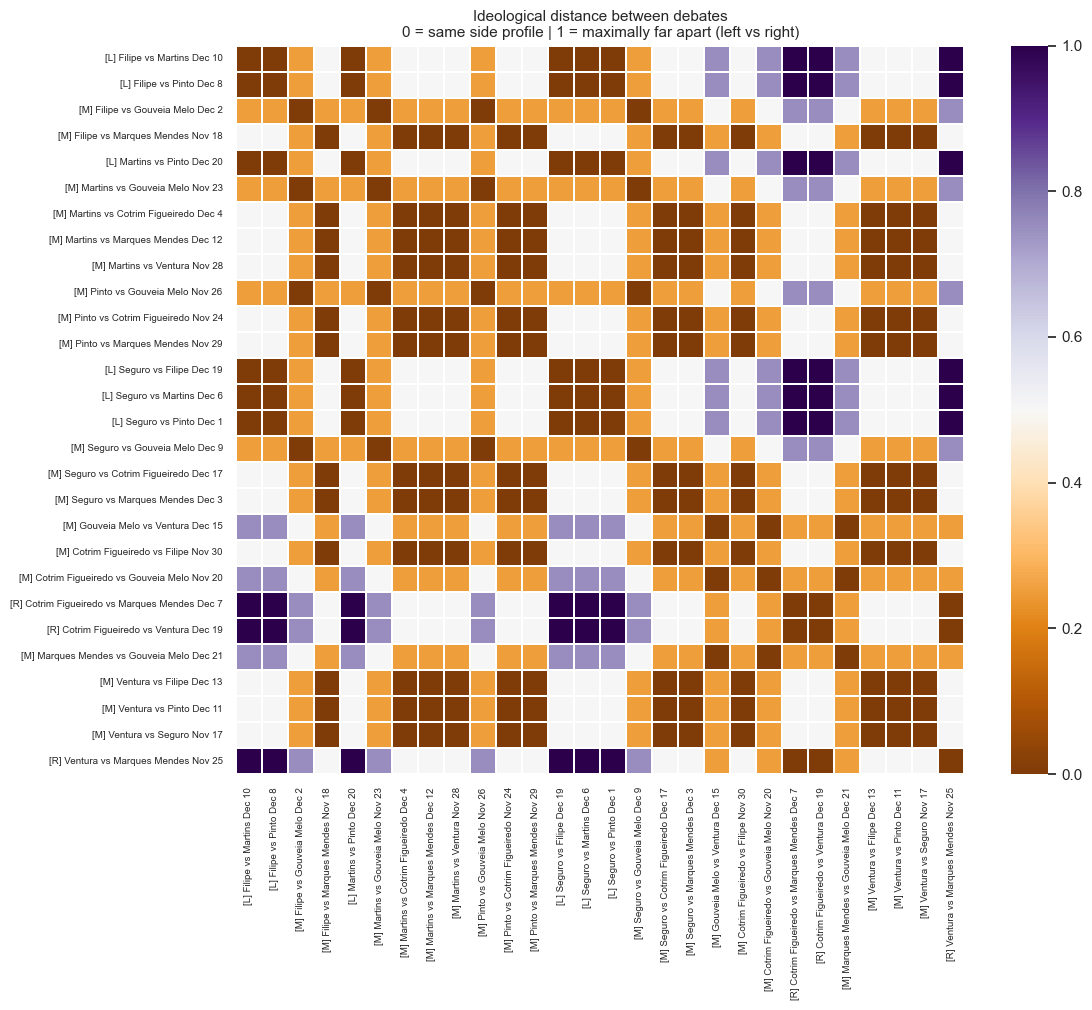

Spearman correlation between semantic distance and ideological distance: rho=0.054, p=0.2919
Most topically similar debate pairs:


,debate_a,debate_b,cosine_distance,ideological_distance,segments_a,segments_b
0,Seguro_vs_Pinto_December_1,Seguro_vs_Marques_Mendes_December_3,0.0014,0.50,36,32
1,Pinto_vs_Cotrim_Figueiredo_November_24,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.0016,0.50,32,33
2,Filipe_vs_Pinto_December_8,Seguro_vs_Filipe_December_19,0.0016,0.00,29,36
3,Seguro_vs_Cotrim_Figueiredo_December_17,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.0016,0.50,28,33
4,Seguro_vs_Marques_Mendes_December_3,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.0016,0.50,32,33
5,Seguro_vs_Filipe_December_19,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.0016,1.00,36,33
6,Pinto_vs_Marques_Mendes_November_29,Seguro_vs_Marques_Mendes_December_3,0.0017,0.00,32,32
7,Seguro_vs_Pinto_December_1,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.0017,1.00,36,33
8,Pinto_vs_Cotrim_Figueiredo_November_24,Seguro_vs_Pinto_December_1,0.0017,0.50,32,36
9,Seguro_vs_Gouveia_Melo_December_9,Seguro_vs_Marques_Mendes_December_3,0.0018,0.25,17,32


Most topically distinct debate pairs:


,debate_a,debate_b,cosine_distance,ideological_distance,segments_a,segments_b
377,Martins_vs_Marques_Mendes_December_12,Martins_vs_Ventura_November_28,0.0139,0.00,33,33
376,Martins_vs_Ventura_November_28,Pinto_vs_Gouveia_Melo_November_26,0.0133,0.25,33,24
375,Martins_vs_Ventura_November_28,Cotrim_Figueiredo_vs_Filipe_November_30,0.0130,0.00,33,33
374,Cotrim_Figueiredo_vs_Filipe_November_30,Marques_Mendes_vs_Gouveia_Melo_December_21,0.0128,0.25,33,35
373,Gouveia_Melo_vs_Ventura_December_15,Cotrim_Figueiredo_vs_Filipe_November_30,0.0127,0.25,21,33
372,Martins_vs_Marques_Mendes_December_12,Marques_Mendes_vs_Gouveia_Melo_December_21,0.0123,0.25,33,35
371,Martins_vs_Gouveia_Melo_November_23,Martins_vs_Ventura_November_28,0.0113,0.25,28,33
370,Filipe_vs_Marques_Mendes_November_18,Martins_vs_Ventura_November_28,0.0112,0.00,33,33
369,Cotrim_Figueiredo_vs_Filipe_November_30,Ventura_vs_Marques_Mendes_November_25,0.0112,0.50,33,32
368,Pinto_vs_Gouveia_Melo_November_26,Marques_Mendes_vs_Gouveia_Melo_December_21,0.0111,0.50,24,35


In [81]:
emb_col = 'text_embedding'

CANDIDATE_ORDER = [
    'Filipe', 'Martins', 'Pinto', 'Seguro',
    'Gouveia_Melo', 'Cotrim_Figueiredo', 'Marques_Mendes', 'Ventura'
]
CANDIDATE_TO_PARTY = {
    'Filipe': 'CDU',
    'Martins': 'BE',
    'Pinto': 'L',
    'Seguro': 'PS',
    'Gouveia_Melo': 'Independent',
    'Cotrim_Figueiredo': 'IL',
    'Marques_Mendes': 'PSD+CDS',
    'Ventura': 'CH',
}
CANDIDATE_TO_IDEOLOGY = {
    'Filipe': 'left',
    'Martins': 'left',
    'Pinto': 'left',
    'Seguro': 'left',
    'Gouveia_Melo': 'independent',
    'Cotrim_Figueiredo': 'right',
    'Marques_Mendes': 'right',
    'Ventura': 'right',
}
IDEOLOGY_SCORE = {'left': -1.0, 'independent': 0.0, 'right': 1.0}


def parse_text_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    if '...' in str(x):
        raise ValueError(
            'text_embedding is truncated (CSV export artifact). '
            'Load the transcript data from the pkl files, not from CSV.'
        )
    return np.fromstring(str(x).strip('[]'), sep=' ')


def extract_candidates_from_debate(video_name):
    for cand_a in CANDIDATE_ORDER:
        prefix = f'{cand_a}_vs_'
        if video_name.startswith(prefix):
            rest = video_name[len(prefix):]
            for cand_b in CANDIDATE_ORDER:
                if rest.startswith(cand_b + '_') or rest == cand_b:
                    return cand_a, cand_b
    return None, None


def pretty_debate_name(video_name):
    return video_name.replace('_vs_', ' vs ').replace('_', ' ').replace('November', 'Nov').replace('December', 'Dec')


transcript_embed_debates = speech_debates.copy()
transcript_embed_debates[emb_col] = transcript_embed_debates[emb_col].apply(parse_text_embedding)

debate_centroids = {}
debate_segment_counts = {}
debate_meta_rows = []
for video, sub in transcript_embed_debates.groupby('video'):
    cand_a, cand_b = extract_candidates_from_debate(video)
    side_a = CANDIDATE_TO_IDEOLOGY.get(cand_a, 'independent')
    side_b = CANDIDATE_TO_IDEOLOGY.get(cand_b, 'independent')
    score_a = IDEOLOGY_SCORE[side_a]
    score_b = IDEOLOGY_SCORE[side_b]

    if side_a == 'left' and side_b == 'left':
        debate_side = 'left'
    elif side_a == 'right' and side_b == 'right':
        debate_side = 'right'
    else:
        debate_side = 'mix'

    debate_centroids[video] = np.stack(sub[emb_col].values).mean(axis=0)
    debate_segment_counts[video] = len(sub)
    debate_meta_rows.append({
        'video': video,
        'candidate_a': cand_a,
        'candidate_b': cand_b,
        'party_a': CANDIDATE_TO_PARTY.get(cand_a),
        'party_b': CANDIDATE_TO_PARTY.get(cand_b),
        'ideology_a': side_a,
        'ideology_b': side_b,
        'debate_ideology': debate_side,
        'ideology_score': (score_a + score_b) / 2,
        'segments': len(sub),
        'pretty_label': pretty_debate_name(video),
    })

debate_meta = pd.DataFrame(debate_meta_rows)
order_map = {c: i for i, c in enumerate(CANDIDATE_ORDER)}
debate_meta['cand_a_order'] = debate_meta['candidate_a'].map(order_map)
debate_meta['cand_b_order'] = debate_meta['candidate_b'].map(order_map)

# One debate belongs to two candidates, so no single ordering can group both perfectly.
# This ordering groups debates by the first candidate in the filename, then by opponent.
debate_meta = debate_meta.sort_values(['cand_a_order', 'cand_b_order', 'video']).reset_index(drop=True)
debate_list = debate_meta['video'].tolist()

centroid_matrix = np.stack([debate_centroids[v] for v in debate_list])
dist_matrix = cdist(centroid_matrix, centroid_matrix, metric='cosine')
dist_df = pd.DataFrame(dist_matrix, index=debate_list, columns=debate_list)

pretty_map = {
    row['video']: f"[{row['debate_ideology'][0].upper()}] {row['pretty_label']}"
    for _, row in debate_meta.iterrows()
}
pretty_labels = [pretty_map[v] for v in debate_list]
dist_df_pretty = pd.DataFrame(dist_matrix, index=pretty_labels, columns=pretty_labels)

print('Debate ordering and ideology labels:')
display(
    debate_meta[
        ['video', 'candidate_a', 'candidate_b', 'party_a', 'party_b', 'debate_ideology', 'ideology_score', 'segments']
    ]
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    dist_df_pretty,
    annot=False,
    cmap='YlOrRd',
    square=True,
    linewidths=0.25,
    ax=ax
)
ax.set_title(
    'Pairwise cosine distance between debate topic centroids\n'
    'Ordered by candidate blocks; labels prefixed with debate ideology (L / M / R)',
    fontsize=11
)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.show()

ideo_scores = debate_meta['ideology_score'].to_numpy()
ideo_dist_matrix = np.abs(ideo_scores[:, None] - ideo_scores[None, :]) / 2.0
ideo_dist_df = pd.DataFrame(ideo_dist_matrix, index=pretty_labels, columns=pretty_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    ideo_dist_df,
    annot=False,
    cmap='PuOr',
    vmin=0, vmax=1,
    square=True,
    linewidths=0.25,
    ax=ax
)
ax.set_title(
    'Ideological distance between debates\n'
    '0 = same side profile | 1 = maximally far apart (left vs right)',
    fontsize=11
)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.show()

upper = np.triu_indices_from(dist_matrix, k=1)
ideo_rho, ideo_p = spearmanr(dist_matrix[upper], ideo_dist_matrix[upper])
print(f'Spearman correlation between semantic distance and ideological distance: rho={ideo_rho:.3f}, p={ideo_p:.4g}')

import itertools
pairs = []
for a, b in itertools.combinations(debate_list, 2):
    pairs.append({
        'debate_a': a,
        'debate_b': b,
        'cosine_distance': dist_df.loc[a, b],
        'ideological_distance': ideo_dist_df.loc[pretty_map[a], pretty_map[b]],
        'segments_a': debate_segment_counts[a],
        'segments_b': debate_segment_counts[b],
    })

pair_df = pd.DataFrame(pairs).sort_values('cosine_distance').reset_index(drop=True)
print('Most topically similar debate pairs:')
display(pair_df.head(10).round(4))
print('Most topically distinct debate pairs:')
display(pair_df.tail(10).sort_values('cosine_distance', ascending=False).round(4))


## 10. Lexical vs semantic debate similarity

Word clouds are useful for interpretation, but the actual comparison below is quantitative:
`TF-IDF` measures lexical overlap while the `text_embedding` centroids measure semantic similarity.
If both views agree, the topic structure across debates is more credible.


Spearman correlation between semantic similarity and lexical similarity: rho=0.515, p=5.598e-27


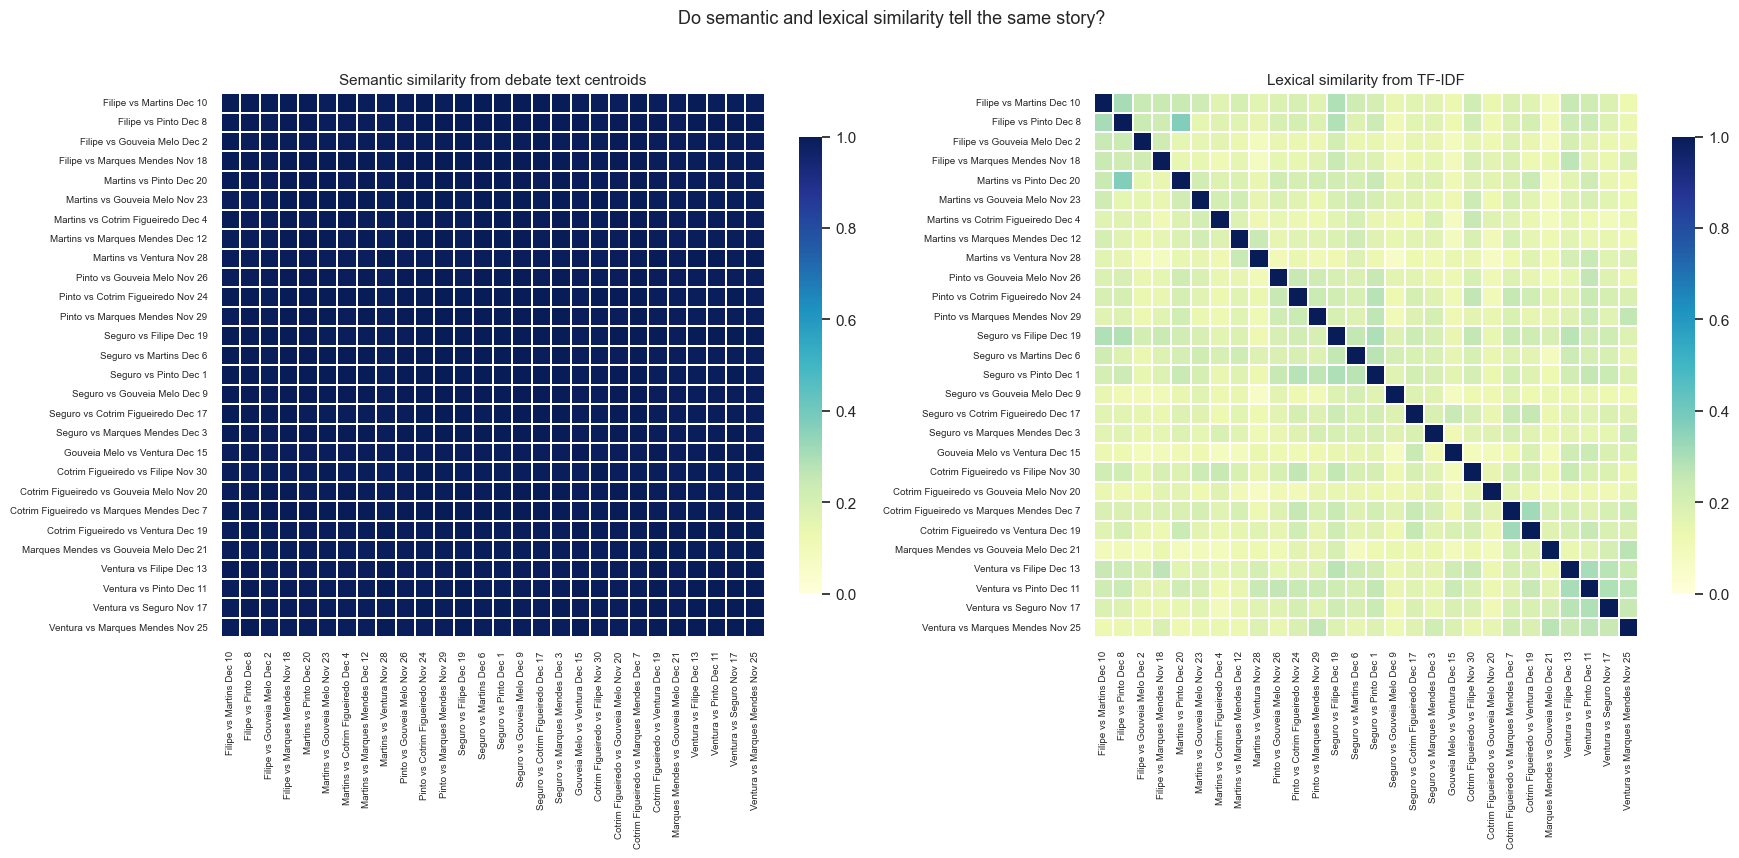

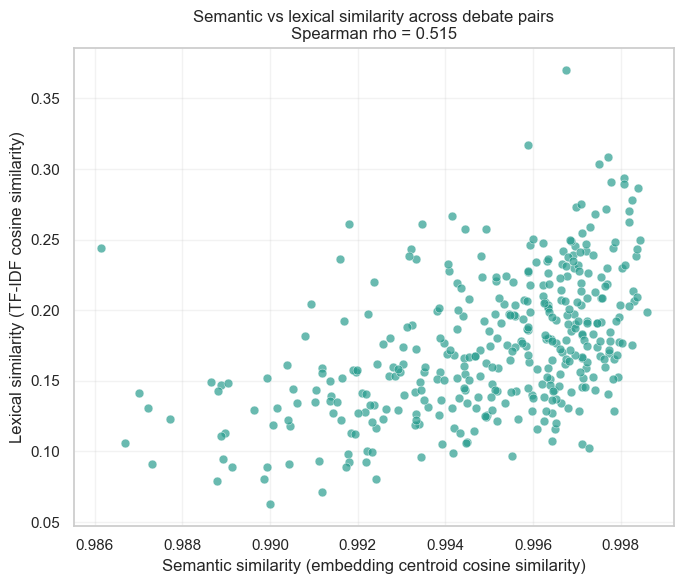

Most semantically similar debate pairs with their lexical similarity:


,debate_a,debate_b,semantic_similarity,lexical_similarity,semantic_distance,lexical_distance
289,Seguro_vs_Pinto_December_1,Seguro_vs_Marques_Mendes_December_3,0.9986,0.1989,0.0014,0.8011
235,Pinto_vs_Cotrim_Figueiredo_November_24,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.9984,0.2500,0.0016,0.7500
37,Filipe_vs_Pinto_December_8,Seguro_vs_Filipe_December_19,0.9984,0.2867,0.0016,0.7133
316,Seguro_vs_Cotrim_Figueiredo_December_17,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.9984,0.2432,0.0016,0.7568
326,Seguro_vs_Marques_Mendes_December_3,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.9984,0.2097,0.0016,0.7903
266,Seguro_vs_Filipe_December_19,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.9984,0.2387,0.0016,0.7613
247,Pinto_vs_Marques_Mendes_November_29,Seguro_vs_Marques_Mendes_December_3,0.9983,0.2069,0.0017,0.7931
293,Seguro_vs_Pinto_December_1,Cotrim_Figueiredo_vs_Marques_Mendes_December_7,0.9983,0.2139,0.0017,0.7861
228,Pinto_vs_Cotrim_Figueiredo_November_24,Seguro_vs_Pinto_December_1,0.9983,0.2779,0.0017,0.7221
301,Seguro_vs_Gouveia_Melo_December_9,Seguro_vs_Marques_Mendes_December_3,0.9982,0.1751,0.0018,0.8249


In [82]:
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

debate_text = (
    speech_debates.groupby('video')['transcript']
    .apply(lambda s: ' '.join(s.dropna().astype(str)))
    .reindex(debate_list)
)

tfidf = TfidfVectorizer(
    stop_words=sorted(PT_STOPWORDS),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    lowercase=True
)
X_tfidf = tfidf.fit_transform(debate_text.values)
lexical_sim_matrix = cosine_similarity(X_tfidf)
lexical_sim_df = pd.DataFrame(lexical_sim_matrix, index=debate_list, columns=debate_list)

semantic_sim_df = 1 - dist_df

upper = np.triu_indices_from(lexical_sim_matrix, k=1)
rho, pval = spearmanr(semantic_sim_df.values[upper], lexical_sim_df.values[upper])
print(f'Spearman correlation between semantic similarity and lexical similarity: rho={rho:.3f}, p={pval:.4g}')

pretty_map = {
    v: v.replace('_vs_', ' vs ').replace('_', ' ').replace('November', 'Nov').replace('December', 'Dec')
    for v in debate_list
}
semantic_sim_pretty = semantic_sim_df.rename(index=pretty_map, columns=pretty_map)
lexical_sim_pretty = lexical_sim_df.rename(index=pretty_map, columns=pretty_map)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(
    semantic_sim_pretty,
    cmap='YlGnBu', vmin=0, vmax=1,
    square=True, linewidths=0.25,
    ax=axes[0], cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Semantic similarity from debate text centroids', fontsize=11)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=7)

sns.heatmap(
    lexical_sim_pretty,
    cmap='YlGnBu', vmin=0, vmax=1,
    square=True, linewidths=0.25,
    ax=axes[1], cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Lexical similarity from TF-IDF', fontsize=11)
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Do semantic and lexical similarity tell the same story?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

compare_pairs = []
for i, a in enumerate(debate_list):
    for b in debate_list[i + 1:]:
        compare_pairs.append({
            'debate_a': a,
            'debate_b': b,
            'semantic_similarity': semantic_sim_df.loc[a, b],
            'lexical_similarity': lexical_sim_df.loc[a, b],
            'semantic_distance': dist_df.loc[a, b],
            'lexical_distance': 1 - lexical_sim_df.loc[a, b],
        })

similarity_compare_df = pd.DataFrame(compare_pairs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    similarity_compare_df['semantic_similarity'],
    similarity_compare_df['lexical_similarity'],
    alpha=0.7, s=40, color='#2a9d8f', edgecolors='white', linewidth=0.4
)
ax.set_xlabel('Semantic similarity (embedding centroid cosine similarity)')
ax.set_ylabel('Lexical similarity (TF-IDF cosine similarity)')
ax.set_title(f'Semantic vs lexical similarity across debate pairs\nSpearman rho = {rho:.3f}')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Most semantically similar debate pairs with their lexical similarity:')
display(similarity_compare_df.sort_values('semantic_similarity', ascending=False).head(10).round(4))


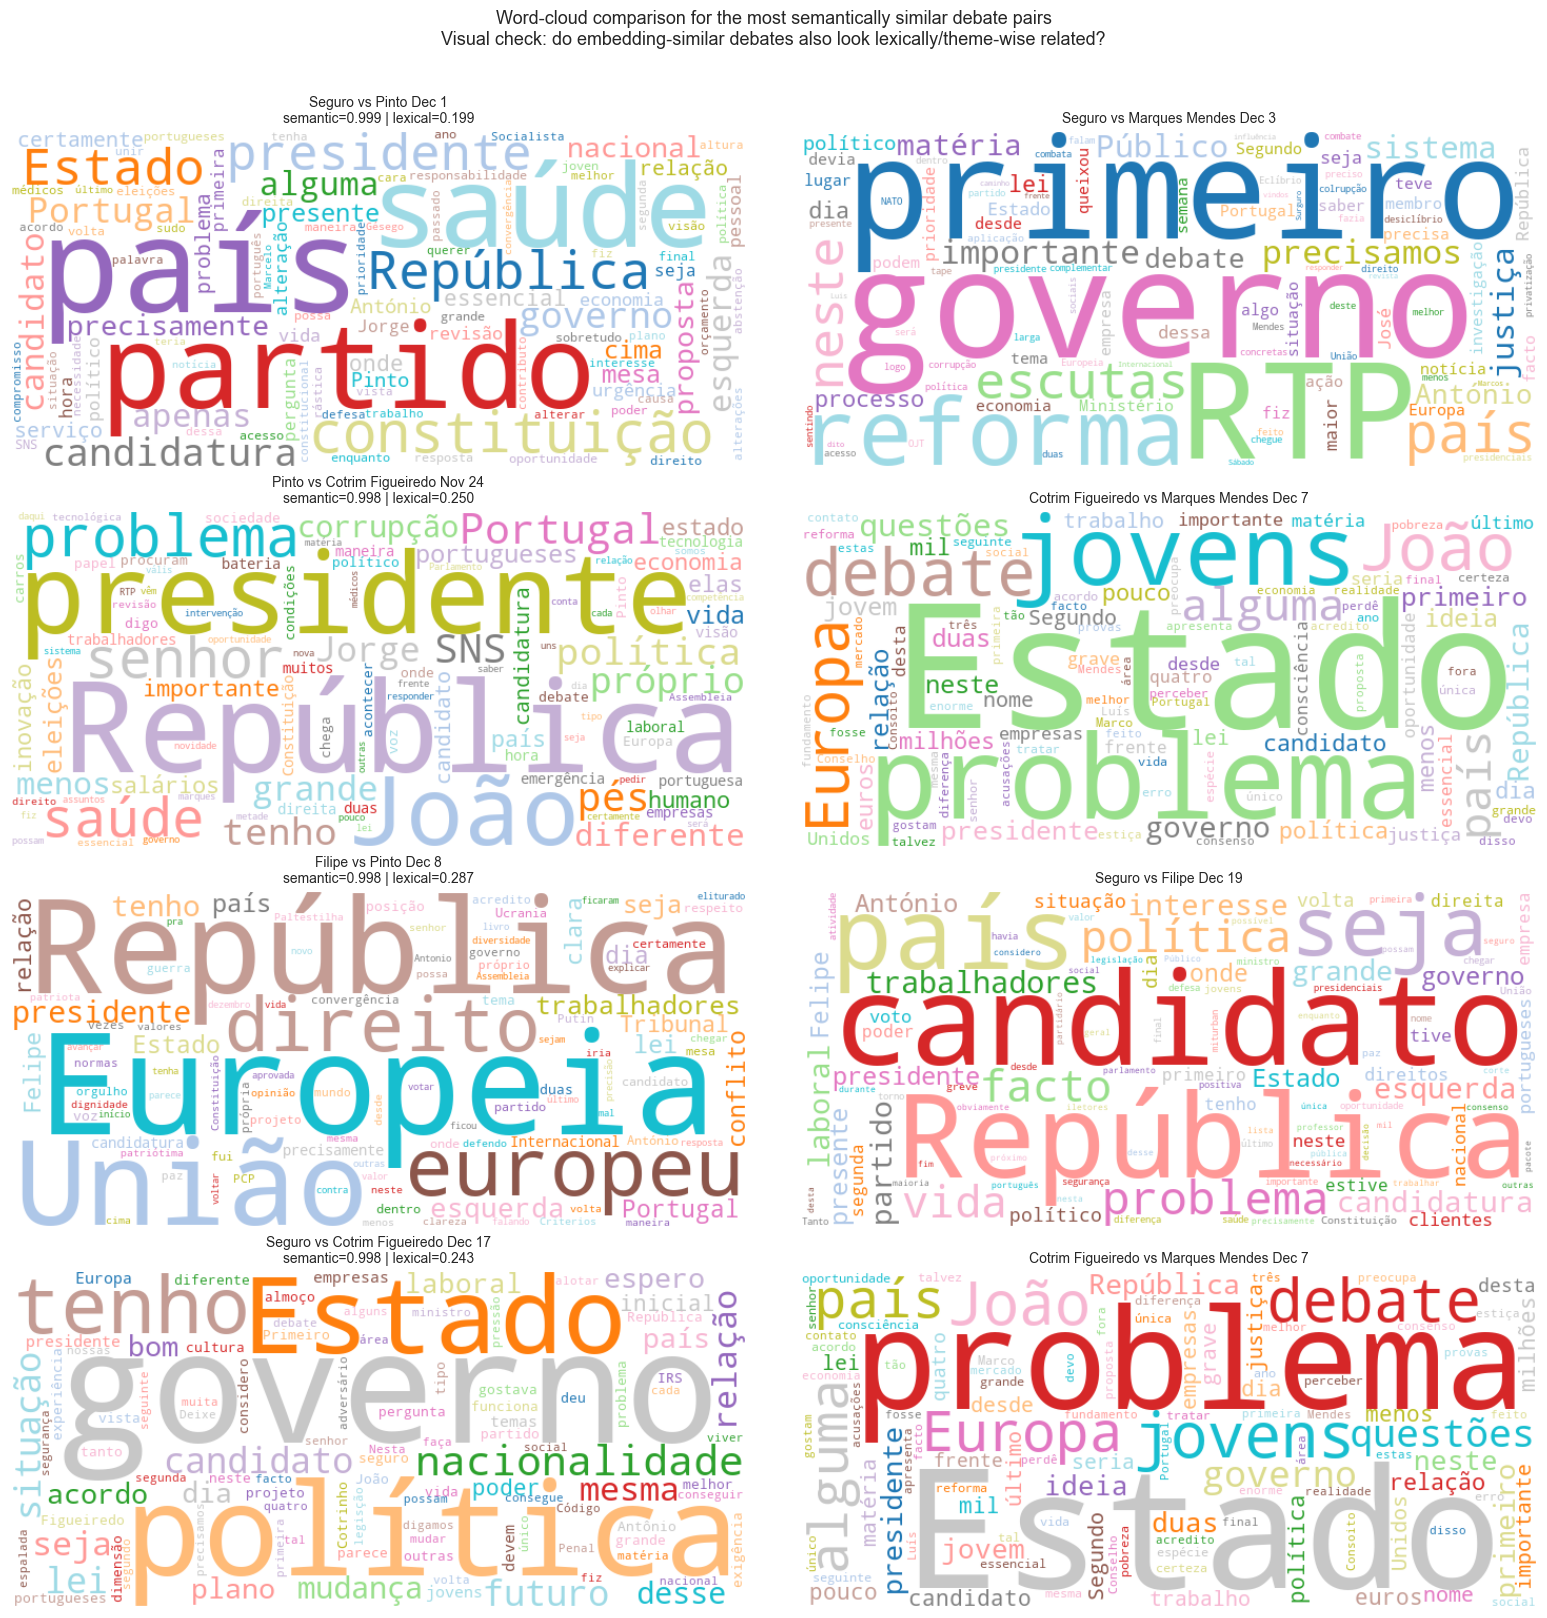

In [83]:
top_semantic_pairs = similarity_compare_df.sort_values('semantic_similarity', ascending=False).head(4).reset_index(drop=True)

fig, axes = plt.subplots(len(top_semantic_pairs), 2, figsize=(16, 4 * len(top_semantic_pairs)))
if len(top_semantic_pairs) == 1:
    axes = np.array([axes])

for row_idx, row in top_semantic_pairs.iterrows():
    a = row['debate_a']
    b = row['debate_b']
    row_text = (
        f"semantic={row['semantic_similarity']:.3f} | lexical={row['lexical_similarity']:.3f}"
    )

    wc_a = WordCloud(
        width=700, height=320,
        background_color='white',
        stopwords=PT_STOPWORDS,
        max_words=100,
        colormap='tab20',
        min_word_length=3,
        collocations=False
    ).generate(debate_text.loc[a])
    axes[row_idx, 0].imshow(wc_a, interpolation='bilinear')
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].set_title(
        f"{pretty_map[a]}\n{row_text}",
        fontsize=10
    )

    wc_b = WordCloud(
        width=700, height=320,
        background_color='white',
        stopwords=PT_STOPWORDS,
        max_words=100,
        colormap='tab20',
        min_word_length=3,
        collocations=False
    ).generate(debate_text.loc[b])
    axes[row_idx, 1].imshow(wc_b, interpolation='bilinear')
    axes[row_idx, 1].axis('off')
    axes[row_idx, 1].set_title(pretty_map[b], fontsize=10)

plt.suptitle(
    'Word-cloud comparison for the most semantically similar debate pairs\n'
    'Visual check: do embedding-similar debates also look lexically/theme-wise related?',
    fontsize=13,
    y=1.01
)
plt.tight_layout()
plt.show()
